# Preliminary ASAP7 voltage analysis in VIP dendrites

This notebook is a first-pass analysis scaffold for the ASAP7 passive DoC sessions. It mirrors the structure of the earlier glutamate analyses but adapts the metrics to fast voltage traces.

Core questions:

1. **Image responses:** Which dendrite ROIs are depolarized, hyperpolarized/suppressed, biphasic, rebound-like, or unchanged by image presentation?
2. **Image identity coding:** How much of the mean response structure, and optionally single-flash trial variance, is attributable to image identity?
3. **Change / omission coding:** Do dendrites show enhanced change responses or omission/ramping dynamics similar to VIP somatic observations?
4. **Sequence dynamics:** Do repeated presentations of an image adapt, facilitate, or remain stable, and are those effects depth- or session-dependent?
5. **Depth/session dependence:** How do the above metrics vary across DMD depth, mouse, and familiar/novel/novel+ session type?

The plotting cells are deliberately explicit: figures are built with `fig, ax = plt.subplots(...)`, followed by direct `ax.plot`, `ax.scatter`, `ax.imshow`, etc., so it is easy to modify aesthetics or swap input data.

In [1]:

# ---------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------
import os
import sys
import glob
import json
import math
import warnings
from pathlib import Path, PureWindowsPath
from datetime import datetime
from collections import defaultdict

import h5py
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, HTML

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from scipy import stats
except Exception:
    stats = None

# Project imports. These are used for session discovery and optional ROI overlays.
try:
    from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
except Exception as exc:
    VIPSessionRegistry = None
    print(f"VIPSessionRegistry import failed: {exc}")

try:
    from vip_slap2_analysis.voltage.summary import VoltageSummary
except Exception as exc:
    VoltageSummary = None
    print(f"VoltageSummary import failed: {exc}")

try:
    from vip_slap2_analysis.common.alignment import (
        load_corrected_bonsai_csv,
        load_imaging_epochs_csv,
        extract_image_intervals,
        extract_change_intervals,
        extract_omission_intervals,
        extract_ordered_change_targets,
        filter_intervals_to_epochs,
        filter_ordered_images_to_epochs,
        build_change_locked_sequences,
    )
except Exception as exc:
    load_corrected_bonsai_csv = None
    print(f"Alignment helper import failed: {exc}")

try:
    from vip_slap2_analysis.utils.utils import save_figure
except Exception:
    save_figure = None

# Optional PNW palettes.
try:
    from PNW_cmap import PNW_cmap
except Exception:
    PNW_cmap = None

warnings.filterwarnings("default")
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:

%load_ext autoreload
%autoreload 2
%matplotlib notebook

## Configuration

The notebook first tries to resolve sessions from the project registry. If you are running this in a temporary/local folder with the uploaded example assets only, set `USE_LOCAL_EXAMPLE_IF_NEEDED=True` and keep the local filenames next to the notebook.

In [3]:

# ---------------------------------------------------------------------
# Paths and dataset selection
# ---------------------------------------------------------------------
today_str = datetime.today().strftime("%Y-%m-%d")

# Main project path on the Allen network.
BASE_PATH = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics")

# Output folder for analysis tables and figures.
SAVE_PATH = Path(
    r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots"
)
SAVE_TABLES = True
SAVE_FIGURES = False

TARGET_MICE = [826031, 826032]
PARADIGMS = ["change_detection_passive"]
EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]

# Extracted voltage analysis outputs.
TRACE_VARIANT = "dff_robust_f0_trial"
SIGNAL = "dff"  # should already be inverted for ASAP7; positive = depolarization

# Local fallbacks, useful when running from the uploaded files in a sandbox or scratch folder.
LOCAL_PROCESS_DF = Path("process_df.csv")
LOCAL_EXAMPLE_MEAN_NPZ = Path("voltage_mean_dff_robust_f0_trial.npz")
LOCAL_EXAMPLE_SEQUENCE_NPZ = Path("voltage_sequence_dff_robust_f0_trial.npz")
LOCAL_EXAMPLE_QC_ZIP = Path("qc.zip")
LOCAL_EXAMPLE_SUMMARY_MAT = Path("dendriticVoltageSummary-260625-155850.mat")
USE_LOCAL_EXAMPLE_IF_NEEDED = True

# Analysis windows. Keep these explicit so you can tune voltage metrics easily.
IMAGE_BASELINE_WINDOW = (-0.25, 0.00)
IMAGE_EARLY_WINDOW = (0.00, 0.05)
IMAGE_STIM_WINDOW = (0.00, 0.25)
IMAGE_POST_WINDOW = (0.25, 0.50)
IMAGE_FULL_RESPONSE_WINDOW = (0.00, 0.50)

CHANGE_BASELINE_WINDOW = (-0.25, 0.00)
CHANGE_PRECHANGE_FLASH_WINDOW = (-0.75, -0.50)
CHANGE_TARGET_WINDOW = (0.00, 0.25)
CHANGE_POST_WINDOW = (0.25, 0.75)

OMISSION_BASELINE_WINDOW = (-0.75, -0.25)
OMISSION_EXPECTED_FLASH_WINDOW = (0.00, 0.25)
OMISSION_RAMP_WINDOW = (0.25, 0.75)
OMISSION_NEXT_FLASH_WINDOW = (0.75, 1.00)

# Response classification thresholds. These are conservative defaults for averaged voltage traces.
CLASS_Z_THRESHOLD = 2.5
CLASS_MIN_ABS_DFF = 0.0025        # absolute dF/F threshold; tune after inspecting examples
BIPHASIC_Z_THRESHOLD = 2.0
SEQUENCE_MIN_COUNT_PER_POSITION = 5
SEQUENCE_MIN_POSITIONS = 4
SEQUENCE_SLOPE_THRESHOLD = 0.0005 # dF/F per image position; tune after inspecting slopes

# Running uses encoder ticks/rev=8192 per manufacturer default; included here for downstream covariate cells.
ENCODER_TICKS_PER_REV = 8192
WHEEL_RADIUS_CM = 4.69

## Aesthetics

I use PNW palettes when available and keep helper functions limited to styling. All plots below remain explicit and editable.

In [4]:

# ---------------------------------------------------------------------
# Plot styling
# ---------------------------------------------------------------------
if sns is not None:
    sns.set_style("white")

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "lines.linewidth": 2.5,
})

def get_pnw_palette(name="Bay", n=8):
    """Return colors, cmap using PNW_cmap when installed; otherwise fallback to tab10/viridis."""
    if PNW_cmap is not None:
        try:
            color_list, cmap, cp = PNW_cmap.get_PNW_cmap(name, n_colors=n)
            return list(cp), cmap
        except Exception as exc:
            print(f"PNW palette {name!r} failed; using fallback. Error: {exc}")
    tab = plt.get_cmap("tab10")
    return [tab(i % 10) for i in range(n)], plt.get_cmap("viridis")

IMAGE_COLORS, IMAGE_CMAP = get_pnw_palette("Bay", 8)
SESSION_COLORS, _ = get_pnw_palette("Sunset2", 8)
DEPTH_COLORS, _ = get_pnw_palette("Cascades", 8)
CLASS_COLORS = {
    "activated": "#dd4124",
    "suppressed": "#00496f",
    "biphasic_pos_neg": "#ed8b00",
    "biphasic_neg_pos": "#0f85a0",
    "rebound": "#89689d",
    "no_change": "#6c757d",
    "unknown": "#adb5bd",
}

def clean_axes(ax):
    ax.tick_params(axis="x", which="major", top=False)
    ax.tick_params(axis="y", which="major", right=False)
    return ax


def maybe_savefig(fig, name, *, folder=SAVE_PATH, transparent=True):
    if not SAVE_FIGURES:
        return None
    folder = Path(folder)
    folder.mkdir(parents=True, exist_ok=True)
    out = folder / f"{today_str}_{name}.png"
    fig.savefig(out, transparent=transparent, bbox_inches="tight")
    print(f"saved: {out}")
    return out

C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\PNW_cmap\PNW_cmap.py:36: MatplotlibDeprecationWarning: The register_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps.register(name)`` instead.
  mpl.cm.register_cmap(palette, cmap)


## Resolve sessions and extracted voltage assets

The main derived assets used here are:

- `voltage_mean_dff_robust_f0_trial.npz`: mean image/change/omission PSTHs.
- `voltage_sequence_dff_robust_f0_trial.npz`: change-locked repeated-image sequence summaries.
- `voltage_session_traces_dff_robust_f0_trial.h5`: full assembled session traces for optional single-trial analyses and timebase QC.

In [5]:

def _path_exists_safe(p):
    try:
        return Path(p).exists()
    except Exception:
        return False


def _coerce_path_or_none(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    try:
        if pd.isna(x):
            return None
    except Exception:
        pass
    return Path(str(x))


def _asset_get(asset, modality, name):
    try:
        return asset.get_asset(modality, name)
    except Exception:
        return None


def resolve_voltage_derived_paths(asset=None, row=None, trace_variant=TRACE_VARIANT):
    """Return canonical derived voltage paths for an asset or process_df row."""
    if asset is not None:
        session_dir = Path(asset.session_dir)
        derived_dir = Path(asset.derived_dir)
        qc_dir = Path(asset.qc_dir)
        voltage_summary_mat = _asset_get(asset, "voltage", "summary_mat")
        raw_voltage_trace_h5 = _asset_get(asset, "voltage", "trace_h5")
    else:
        session_dir = Path(str(row["session_dir"]))
        derived_dir = session_dir / "analysis" / "derived"
        qc_dir = session_dir / "analysis" / "qc"
        # Registry is better for these; row fallback uses recursive search only if the path is available.
        mats = list(session_dir.glob("**/dendriticVoltageSummary*.mat")) if session_dir.exists() else []
        h5s = list(session_dir.glob("**/dendriticVoltageTraces*.h5")) if session_dir.exists() else []
        voltage_summary_mat = max(mats, key=lambda p: p.stat().st_mtime) if mats else None
        raw_voltage_trace_h5 = max(h5s, key=lambda p: p.stat().st_mtime) if h5s else None

    derived_voltage_dir = derived_dir / "voltage"
    return {
        "session_dir": session_dir,
        "derived_dir": derived_dir,
        "qc_dir": qc_dir,
        "mean_npz": derived_voltage_dir / f"voltage_mean_{trace_variant}.npz",
        "sequence_npz": derived_voltage_dir / f"voltage_sequence_{trace_variant}.npz",
        "session_trace_h5": derived_voltage_dir / f"voltage_session_traces_{trace_variant}.h5",
        "voltage_summary_mat": voltage_summary_mat,
        "raw_voltage_trace_h5": raw_voltage_trace_h5,
        "roi_qc_csv": qc_dir / "voltage" / "voltage_roi_qc.csv",
        "trial_qc_csv": qc_dir / "voltage" / "voltage_trial_qc.csv",
        "imaging_epochs_csv": qc_dir / "behavior" / "imaging_epochs.csv",
        "behavior_validation_json": qc_dir / "behavior" / "behavior_validation.json",
    }


def load_process_df_and_assets():
    """Use the registry when possible; otherwise fall back to LOCAL_PROCESS_DF."""
    assets = None
    if VIPSessionRegistry is not None:
        try:
            registry = VIPSessionRegistry.from_basepath(BASE_PATH)
            process_df = registry.sessions(
                subject_ids=TARGET_MICE,
                exclude_session_types=EXCLUDE_SESSION_TYPES,
                paradigms=PARADIGMS,
            )
            assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]
            print(f"Found {len(assets)} sessions from registry.")
            return process_df, assets
        except Exception as exc:
            print(f"Registry resolution failed; trying local process_df. Error: {exc}")

    if LOCAL_PROCESS_DF.exists():
        process_df = pd.read_csv(LOCAL_PROCESS_DF)
        print(f"Loaded local process_df: {LOCAL_PROCESS_DF} ({len(process_df)} rows)")
        return process_df, None

    raise FileNotFoundError("Could not resolve registry sessions and LOCAL_PROCESS_DF does not exist.")


process_df, assets = load_process_df_and_assets()

def build_session_table(process_df, assets=None):
    rows = []
    for i, row in process_df.reset_index(drop=True).iterrows():
        asset = assets[i] if assets is not None else None
        paths = resolve_voltage_derived_paths(asset=asset, row=row)
        out = row.to_dict()
        out.update({k: str(v) if v is not None else None for k, v in paths.items()})
        out.update({f"{k}_exists": _path_exists_safe(v) for k, v in paths.items() if k.endswith(("npz", "h5", "mat", "csv", "json"))})
        rows.append(out)
    return pd.DataFrame(rows)

session_table = build_session_table(process_df, assets)

# If running only on uploaded example files, make a one-row local table when network paths are not visible.
if USE_LOCAL_EXAMPLE_IF_NEEDED and not session_table["mean_npz_exists"].any() and LOCAL_EXAMPLE_MEAN_NPZ.exists():
    ex = np.load(LOCAL_EXAMPLE_MEAN_NPZ, allow_pickle=True)["data"][0]
    sid = ex["metadata"].get("session_id", "local_example")
    matching = process_df.loc[process_df["session_id"].astype(str).eq(str(sid))]
    if len(matching):
        base = matching.iloc[0].to_dict()
    else:
        base = {"session_id": sid, "subject_id": ex["metadata"].get("subject_id", np.nan)}
    base.update({
        "mean_npz": str(LOCAL_EXAMPLE_MEAN_NPZ),
        "sequence_npz": str(LOCAL_EXAMPLE_SEQUENCE_NPZ),
        "session_trace_h5": None,
        "voltage_summary_mat": str(LOCAL_EXAMPLE_SUMMARY_MAT) if LOCAL_EXAMPLE_SUMMARY_MAT.exists() else None,
        "qc_dir": None,
        "dmd1_depth": base.get("dmd1_depth", np.nan),
        "dmd2_depth": base.get("dmd2_depth", np.nan),
        "session_type": base.get("session_type", "unknown"),
        "stimulus": base.get("stimulus", "unknown"),
        "session_#": base.get("session_#", np.nan),
    })
    base.update({
        "mean_npz_exists": True,
        "sequence_npz_exists": LOCAL_EXAMPLE_SEQUENCE_NPZ.exists(),
        "session_trace_h5_exists": False,
        "voltage_summary_mat_exists": LOCAL_EXAMPLE_SUMMARY_MAT.exists(),
    })
    session_table = pd.DataFrame([base])
    print("Using local example NPZ files because network derived files were not visible.")

print(session_table[["session_id", "subject_id", "session_#", "session_type", "stimulus", "dmd1_depth", "dmd2_depth", "mean_npz_exists", "sequence_npz_exists", "session_trace_h5_exists"]].to_string(index=False))
display(session_table.head())

Found 19 sessions from registry.
                session_id  subject_id  session_# session_type stimulus  dmd1_depth  dmd2_depth  mean_npz_exists  sequence_npz_exists  session_trace_h5_exists
826031_2026-01-30_15-04-02      826031          2     familiar images_A          50         250             True                 True                     True
826031_2026-02-01_11-01-50      826031          3     familiar images_A          50         250             True                 True                     True
826031_2026-02-02_10-23-53      826031          4     familiar images_A          50         250             True                 True                     True
826031_2026-02-03_14-21-45      826031          5     familiar images_A          50         250             True                 True                     True
826031_2026-02-04_12-15-34      826031          6     familiar images_A          50         250             True                 True                     True
826031_2026-0

,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,behavior_validation_json,mean_npz_exists,sequence_npz_exists,session_trace_h5_exists,voltage_summary_mat_exists,raw_voltage_trace_h5_exists,roi_qc_csv_exists,trial_qc_csv_exists,imaging_epochs_csv_exists,behavior_validation_json_exists
0,826031_2026-01-30_15-04-02,826031,2,2026-01-30,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,True,True,True,True,True,True,True
1,826031_2026-02-01_11-01-50,826031,3,2026-02-01,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,True,True,True,True,True,True,True
2,826031_2026-02-02_10-23-53,826031,4,2026-02-02,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,True,True,True,True,True,True,True
3,826031_2026-02-03_14-21-45,826031,5,2026-02-03,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,True,True,True,True,True,True,True
4,826031_2026-02-04_12-15-34,826031,6,2026-02-04,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,True,True,True,True,True,True,True


## Load derived mean and sequence packages

These packages are small enough to load into memory for all sessions. Full session H5 traces are left on disk and used only by optional QC/single-trial cells.

In [6]:

def load_npz_object(path):
    path = Path(path)
    obj = np.load(path, allow_pickle=True)["data"]
    if obj.shape == (1,):
        return obj[0]
    return obj.item()


def stim_label(stim_name):
    """Short stimulus label that works for Windows-style paths stored in Bonsai."""
    if stim_name is None:
        return "None"
    s = str(stim_name).replace("/", "\\")
    try:
        return PureWindowsPath(s).stem
    except Exception:
        return Path(s).stem


def dmd_depth_from_row(row, dmd):
    return row.get(f"dmd{int(dmd)}_depth", np.nan)


def load_all_packages(session_table):
    mean_packages = {}
    sequence_packages = {}
    for _, row in session_table.iterrows():
        sid = str(row["session_id"])
        mean_path = Path(str(row["mean_npz"])) if pd.notna(row.get("mean_npz")) else None
        seq_path = Path(str(row["sequence_npz"])) if pd.notna(row.get("sequence_npz")) else None
        if mean_path is not None and mean_path.exists():
            mean_packages[sid] = load_npz_object(mean_path)
        if seq_path is not None and seq_path.exists():
            sequence_packages[sid] = load_npz_object(seq_path)
    return mean_packages, sequence_packages

mean_packages, sequence_packages = load_all_packages(session_table)
print(f"Loaded {len(mean_packages)} mean packages and {len(sequence_packages)} sequence packages.")

if mean_packages:
    sid0 = next(iter(mean_packages))
    pkg0 = mean_packages[sid0]
    print("Example session:", sid0)
    print("metadata:", {k: pkg0["metadata"].get(k) for k in ["session_id", "subject_id", "sample_rate_hz", "trace_mode", "trace_suffix", "epoch_start_sec", "epoch_end_sec"]})
    print("timebases:", {k: (v.shape, float(v[0]), float(v[-1])) for k, v in pkg0["timebase_sec"].items()})

Loaded 19 mean packages and 19 sequence packages.
Example session: 826031_2026-01-30_15-04-02
metadata: {'session_id': '826031_2026-01-30_15-04-02', 'subject_id': 826031, 'sample_rate_hz': 10686.6669921875, 'trace_mode': 'trial', 'trace_suffix': 'dff_robust_f0_trial', 'epoch_start_sec': 6.386655999987852, 'epoch_end_sec': 1800.1150400000042}
timebases: {'image': ((8016,), -0.25, 0.49999997715459177), 'change': ((18702,), -1.0, 0.7499375636641323), 'omission': ((26717,), -1.0, 1.499937540818724)}


## Optional: epoch/gap QC for the full session H5

Run this before trusting subtle timing metrics. A useful sanity check is whether `timebase_sec` contains large gaps when there were multiple imaging epochs, and whether `trial_starts_sec` agrees with the behavior QC epoch table.

In [7]:

def inspect_voltage_session_h5(trace_h5, dmd="DMD1"):
    """Summarize timebase spacing, trial starts, and validity for one DMD in a session trace H5."""
    trace_h5 = Path(trace_h5)
    if not trace_h5.exists():
        raise FileNotFoundError(trace_h5)
    with h5py.File(trace_h5, "r") as f:
        g = f[dmd]
        t = np.asarray(g["timebase_sec"])
        dt = np.diff(t)
        med_dt = float(np.nanmedian(dt)) if dt.size else np.nan
        gap_threshold = 5 * med_dt if np.isfinite(med_dt) else np.nan
        gap_idx = np.where(dt > gap_threshold)[0] if np.isfinite(gap_threshold) else np.array([], dtype=int)
        out = {
            "trace_h5": str(trace_h5),
            "dmd": dmd,
            "n_rois": int(g[SIGNAL].shape[0]) if SIGNAL in g else np.nan,
            "n_samples": int(t.size),
            "sample_rate_hz_from_timebase": float(1.0 / med_dt) if med_dt > 0 else np.nan,
            "time_start_sec": float(t[0]),
            "time_end_sec": float(t[-1]),
            "median_dt_sec": med_dt,
            "max_dt_sec": float(np.nanmax(dt)) if dt.size else np.nan,
            "n_timebase_gaps_gt_5x_median": int(gap_idx.size),
            "first_few_gap_times_sec": t[gap_idx[:10]].tolist() if gap_idx.size else [],
        }
        for key in ["trial_starts_sec", "trial_lengths_samples", "trial_valid_mask"]:
            if key in g:
                arr = np.asarray(g[key])
                out[key + "_shape"] = arr.shape
                if key == "trial_valid_mask":
                    out["n_valid_trials"] = int(arr.sum())
                else:
                    out[key + "_first5"] = arr[:5].tolist()
                    out[key + "_last5"] = arr[-5:].tolist()
        return out


def load_json_or_none(path):
    path = Path(path)
    if not path.exists():
        return None
    with open(path, "r") as f:
        return json.load(f)

# Choose the first session with an H5 visible.
h5_rows = session_table.loc[session_table.get("session_trace_h5_exists", False).astype(bool)] if "session_trace_h5_exists" in session_table else pd.DataFrame()
if len(h5_rows):
    row = h5_rows.iloc[0]
    qc = inspect_voltage_session_h5(row["session_trace_h5"], dmd="DMD1")
    display(pd.Series(qc).to_frame("value"))

    epochs_csv = Path(str(row.get("imaging_epochs_csv", "")))
    if epochs_csv.exists():
        epoch_df = pd.read_csv(epochs_csv)
        display(epoch_df)
    else:
        print("No imaging_epochs.csv found for visible H5 session.")
else:
    print("No full session H5 visible. This QC cell will run on the network when session_trace_h5 exists.")

,value
trace_h5,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
dmd,DMD1
n_rois,15
n_samples,19236241
sample_rate_hz_from_timebase,10724.166027
time_start_sec,6.386656
time_end_sec,1800.114947
median_dt_sec,0.000093
max_dt_sec,0.000093
n_timebase_gaps_gt_5x_median,0


,epoch_index,start_idx,end_idx,start_time,end_time,duration_s
0,1,1,440664,6.386656,1800.11504,1793.728384


# Core metric helpers

All response metrics are baseline-subtracted. For voltage, the default response scalar is the mean dF/F in a response window minus the mean dF/F in a baseline window. Because ASAP7 dF/F has already been inverted, positive values should correspond to depolarization-associated fluorescence decreases.

In [8]:

EPS = np.finfo(float).eps


def time_mask(t, window):
    t = np.asarray(t)
    start, stop = window
    return (t >= start) & (t < stop)


def window_mean(trace, t, window):
    mask = time_mask(t, window)
    if not np.any(mask):
        return np.nan
    return float(np.nanmean(np.asarray(trace)[mask]))


def window_peak(trace, t, window, mode="max"):
    mask = time_mask(t, window)
    if not np.any(mask):
        return np.nan, np.nan
    y = np.asarray(trace)[mask]
    tt = np.asarray(t)[mask]
    if y.size == 0 or np.all(~np.isfinite(y)):
        return np.nan, np.nan
    idx = np.nanargmax(y) if mode == "max" else np.nanargmin(y)
    return float(y[idx]), float(tt[idx])


def baseline_subtracted_trace(trace, t, baseline_window=IMAGE_BASELINE_WINDOW):
    b = window_mean(trace, t, baseline_window)
    return np.asarray(trace, dtype=float) - b


def response_scalar(trace, t, response_window=IMAGE_STIM_WINDOW, baseline_window=IMAGE_BASELINE_WINDOW):
    return window_mean(trace, t, response_window) - window_mean(trace, t, baseline_window)


def response_auc(trace, t, response_window=IMAGE_STIM_WINDOW, baseline_window=IMAGE_BASELINE_WINDOW):
    y = baseline_subtracted_trace(trace, t, baseline_window)
    mask = time_mask(t, response_window)
    if not np.any(mask):
        return np.nan
    return float(np.trapz(y[mask], t[mask]))


def sem_of_window(std_trace, n_events, t, window):
    """Approximate SEM of a window-mean from per-timepoint event std stored in the mean NPZ."""
    n = float(np.asarray(n_events).squeeze())
    if not np.isfinite(n) or n <= 1:
        return np.nan
    mask = time_mask(t, window)
    if not np.any(mask):
        return np.nan
    # Conservative: average pointwise variance across the window, then divide by n.
    v = np.nanmean(np.asarray(std_trace)[mask] ** 2)
    return float(np.sqrt(v / n))


def delta_zscore(mean_trace, std_trace, n_events, t, response_window, baseline_window):
    delta = response_scalar(mean_trace, t, response_window, baseline_window)
    sem_r = sem_of_window(std_trace, n_events, t, response_window)
    sem_b = sem_of_window(std_trace, n_events, t, baseline_window)
    denom = np.sqrt(sem_r**2 + sem_b**2) if np.isfinite(sem_r) and np.isfinite(sem_b) else np.nan
    if not np.isfinite(denom) or denom <= EPS:
        return np.nan
    return float(delta / denom)


def lifetime_sparseness(responses):
    """Vinje-Gallant lifetime sparseness over image responses."""
    r = np.asarray(responses, dtype=float)
    r = r[np.isfinite(r)]
    n = r.size
    if n <= 1:
        return np.nan
    denom = np.nanmean(r ** 2)
    if denom <= EPS:
        return 0.0
    return float((1.0 - (np.nanmean(r) ** 2) / denom) / (1.0 - 1.0 / n))


def common_vs_identity_mean_trace_variance(mean_traces):
    """
    Variance decomposition across image-mean traces.

    This is not a single-trial FVE. It answers: of the variance in the set of mean
    image PSTHs, how much is a common image-triggered waveform vs image-specific
    deviations from that common waveform?
    """
    X = np.asarray(mean_traces, dtype=float)
    out = {
        "mean_trace_total_var": np.nan,
        "common_trace_fraction": np.nan,
        "identity_deviation_fraction": np.nan,
    }
    if X.ndim != 2 or X.shape[0] < 2:
        return out
    total = float(np.nanvar(X))
    if not np.isfinite(total) or total <= EPS:
        out.update({"mean_trace_total_var": total, "common_trace_fraction": 0.0, "identity_deviation_fraction": 0.0})
        return out
    common = np.nanmean(X, axis=0)
    resid = X - common[None, :]
    resid_var = float(np.nanvar(resid))
    out.update({
        "mean_trace_total_var": total,
        "common_trace_fraction": float(1.0 - resid_var / total),
        "identity_deviation_fraction": float(resid_var / total),
    })
    return out


def classify_image_response(row):
    """Classify ROI-level image response dynamics from preferred positive/negative image metrics."""
    pos = row.get("preferred_positive_z", np.nan)
    neg = row.get("preferred_negative_z", np.nan)
    pos_amp = row.get("preferred_positive_delta", np.nan)
    neg_amp = row.get("preferred_negative_delta", np.nan)
    post = row.get("preferred_post_delta", np.nan)
    stim = row.get("preferred_abs_stim_delta", np.nan)
    tpos = row.get("preferred_positive_t_peak", np.nan)
    tneg = row.get("preferred_negative_t_peak", np.nan)

    pos_sig = np.isfinite(pos) and pos >= CLASS_Z_THRESHOLD and np.isfinite(pos_amp) and pos_amp >= CLASS_MIN_ABS_DFF
    neg_sig = np.isfinite(neg) and neg <= -CLASS_Z_THRESHOLD and np.isfinite(neg_amp) and abs(neg_amp) >= CLASS_MIN_ABS_DFF
    pos_loose = np.isfinite(pos) and pos >= BIPHASIC_Z_THRESHOLD and np.isfinite(pos_amp) and pos_amp >= CLASS_MIN_ABS_DFF
    neg_loose = np.isfinite(neg) and neg <= -BIPHASIC_Z_THRESHOLD and np.isfinite(neg_amp) and abs(neg_amp) >= CLASS_MIN_ABS_DFF

    if pos_loose and neg_loose:
        if np.isfinite(tpos) and np.isfinite(tneg) and tpos < tneg:
            return "biphasic_pos_neg"
        return "biphasic_neg_pos"
    if pos_sig:
        return "activated"
    if neg_sig:
        # If the strongest positive component is delayed until after offset, call it rebound.
        if np.isfinite(post) and post > CLASS_MIN_ABS_DFF and np.isfinite(stim) and stim < CLASS_MIN_ABS_DFF:
            return "rebound"
        return "suppressed"
    return "no_change"


def weighted_slope(x, y, w=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    if w is not None:
        w = np.asarray(w, dtype=float)
        finite &= np.isfinite(w) & (w > 0)
    if finite.sum() < 2:
        return np.nan, np.nan
    x = x[finite]
    y = y[finite]
    if w is None:
        coef = np.polyfit(x, y, deg=1)
    else:
        coef = np.polyfit(x, y, deg=1, w=np.sqrt(w[finite]))
    return float(coef[0]), float(coef[1])


def classify_sequence_slope(slope, threshold=SEQUENCE_SLOPE_THRESHOLD):
    if not np.isfinite(slope):
        return "unknown"
    if slope >= threshold:
        return "facilitating"
    if slope <= -threshold:
        return "adapting"
    return "stable"

# Build image response tables

`image_response_df` is per session × DMD × ROI × image.

`roi_response_summary` is per session × DMD × ROI and contains the preferred-response classification and image-identity metrics.

In [9]:

def package_session_metadata(session_id):
    row = session_table.loc[session_table["session_id"].astype(str).eq(str(session_id))]
    if len(row):
        return row.iloc[0].to_dict()
    return {"session_id": session_id}


def compute_image_response_tables(mean_packages):
    image_rows = []
    roi_rows = []
    for session_id, pkg in mean_packages.items():
        meta = package_session_metadata(session_id)
        t = np.asarray(pkg["timebase_sec"]["image"], dtype=float)
        # Some mean arrays are one sample shorter than stored timebase because of np.arange rounding.
        for dmd_name in [k for k in pkg.keys() if str(k).startswith("DMD")]:
            dmd = int(str(dmd_name).replace("DMD", ""))
            dmd_data = pkg[dmd_name]
            roi_ids = [str(x) for x in dmd_data.get("roi_ids", [])]
            depth = meta.get(f"dmd{dmd}_depth", np.nan)
            stim_dict = dmd_data.get("image_identity", {})
            if not stim_dict or len(roi_ids) == 0:
                continue

            # Per-image rows.
            per_roi_scalar = defaultdict(list)
            per_roi_traces = defaultdict(list)
            for stim_idx, (stim_name, stim_data) in enumerate(stim_dict.items()):
                mean_arr = np.asarray(stim_data["mean"], dtype=float)
                std_arr = np.asarray(stim_data.get("std", np.full_like(mean_arr, np.nan)), dtype=float)
                n_events = int(np.asarray(stim_data.get("n_events", np.nan)).squeeze())
                tt = t[: mean_arr.shape[1]]
                for roi_idx, roi_id in enumerate(roi_ids):
                    y = mean_arr[roi_idx]
                    yb = baseline_subtracted_trace(y, tt, IMAGE_BASELINE_WINDOW)
                    std_y = std_arr[roi_idx] if std_arr.ndim == 2 else np.full_like(y, np.nan)

                    stim_delta = response_scalar(y, tt, IMAGE_STIM_WINDOW, IMAGE_BASELINE_WINDOW)
                    early_delta = response_scalar(y, tt, IMAGE_EARLY_WINDOW, IMAGE_BASELINE_WINDOW)
                    post_delta = response_scalar(y, tt, IMAGE_POST_WINDOW, IMAGE_BASELINE_WINDOW)
                    full_delta = response_scalar(y, tt, IMAGE_FULL_RESPONSE_WINDOW, IMAGE_BASELINE_WINDOW)
                    auc = response_auc(y, tt, IMAGE_FULL_RESPONSE_WINDOW, IMAGE_BASELINE_WINDOW)
                    peak_pos, t_peak_pos = window_peak(yb, tt, IMAGE_FULL_RESPONSE_WINDOW, mode="max")
                    peak_neg, t_peak_neg = window_peak(yb, tt, IMAGE_FULL_RESPONSE_WINDOW, mode="min")
                    z_stim = delta_zscore(y, std_y, n_events, tt, IMAGE_STIM_WINDOW, IMAGE_BASELINE_WINDOW)
                    z_full = delta_zscore(y, std_y, n_events, tt, IMAGE_FULL_RESPONSE_WINDOW, IMAGE_BASELINE_WINDOW)

                    image_rows.append({
                        "session_id": session_id,
                        "subject_id": meta.get("subject_id", pkg.get("metadata", {}).get("subject_id", np.nan)),
                        "session_number": meta.get("session_#", meta.get("session_number", np.nan)),
                        "session_date": meta.get("session_date", np.nan),
                        "session_type": meta.get("session_type", "unknown"),
                        "stimulus_set": meta.get("stimulus", "unknown"),
                        "dmd": dmd,
                        "depth_um": depth,
                        "roi_idx": roi_idx,
                        "roi_id": roi_id,
                        "stimulus_name": str(stim_name),
                        "stimulus_label": stim_label(stim_name),
                        "stimulus_index": stim_idx,
                        "n_events": n_events,
                        "baseline_mean": window_mean(y, tt, IMAGE_BASELINE_WINDOW),
                        "early_delta": early_delta,
                        "stim_delta": stim_delta,
                        "post_delta": post_delta,
                        "full_delta": full_delta,
                        "auc_full": auc,
                        "peak_positive": peak_pos,
                        "t_peak_positive": t_peak_pos,
                        "peak_negative": peak_neg,
                        "t_peak_negative": t_peak_neg,
                        "z_stim": z_stim,
                        "z_full": z_full,
                    })
                    per_roi_scalar[roi_idx].append(stim_delta)
                    per_roi_traces[roi_idx].append(yb)

            # ROI-level summary rows.
            per_image_df = pd.DataFrame([r for r in image_rows if r["session_id"] == session_id and r["dmd"] == dmd])
            for roi_idx, roi_id in enumerate(roi_ids):
                sub = per_image_df.loc[per_image_df["roi_idx"].eq(roi_idx)].copy()
                if sub.empty:
                    continue
                pos_row = sub.loc[sub["peak_positive"].idxmax()]
                neg_row = sub.loc[sub["peak_negative"].idxmin()]
                abs_row = sub.iloc[np.nanargmax(np.abs(sub["stim_delta"].to_numpy(dtype=float)))]
                variance_parts = common_vs_identity_mean_trace_variance(np.asarray(per_roi_traces[roi_idx]))
                scalar_responses = sub["stim_delta"].to_numpy(dtype=float)
                roi_row = {
                    "session_id": session_id,
                    "subject_id": meta.get("subject_id", pkg.get("metadata", {}).get("subject_id", np.nan)),
                    "session_number": meta.get("session_#", meta.get("session_number", np.nan)),
                    "session_date": meta.get("session_date", np.nan),
                    "session_type": meta.get("session_type", "unknown"),
                    "stimulus_set": meta.get("stimulus", "unknown"),
                    "dmd": dmd,
                    "depth_um": depth,
                    "roi_idx": roi_idx,
                    "roi_id": roi_id,
                    "n_images": int(sub["stimulus_label"].nunique()),
                    "mean_stim_delta": float(np.nanmean(scalar_responses)),
                    "median_stim_delta": float(np.nanmedian(scalar_responses)),
                    "std_stim_delta_across_images": float(np.nanstd(scalar_responses)),
                    "range_stim_delta_across_images": float(np.nanmax(scalar_responses) - np.nanmin(scalar_responses)),
                    "lifetime_sparseness_stim_delta": lifetime_sparseness(np.maximum(scalar_responses, 0)),
                    "preferred_positive_image": pos_row["stimulus_label"],
                    "preferred_positive_delta": float(pos_row["peak_positive"]),
                    "preferred_positive_z": float(pos_row["z_full"]),
                    "preferred_positive_t_peak": float(pos_row["t_peak_positive"]),
                    "preferred_negative_image": neg_row["stimulus_label"],
                    "preferred_negative_delta": float(neg_row["peak_negative"]),
                    "preferred_negative_z": float(neg_row["z_full"]),
                    "preferred_negative_t_peak": float(neg_row["t_peak_negative"]),
                    "preferred_abs_image": abs_row["stimulus_label"],
                    "preferred_abs_stim_delta": float(abs_row["stim_delta"]),
                    "preferred_post_delta": float(abs_row["post_delta"]),
                }
                roi_row.update(variance_parts)
                roi_row["response_class"] = classify_image_response(roi_row)
                roi_rows.append(roi_row)

    image_response_df = pd.DataFrame(image_rows)
    roi_response_summary = pd.DataFrame(roi_rows)
    return image_response_df, roi_response_summary

image_response_df, roi_response_summary = compute_image_response_tables(mean_packages)
print("image_response_df", image_response_df.shape)
print("roi_response_summary", roi_response_summary.shape)
display(roi_response_summary.head())

if SAVE_TABLES and len(roi_response_summary):
    table_dir = SAVE_PATH / "tables"
    try:
        table_dir.mkdir(parents=True, exist_ok=True)
        image_response_df.to_csv(table_dir / f"{today_str}_asap7_image_response_per_image.csv", index=False)
        roi_response_summary.to_csv(table_dir / f"{today_str}_asap7_image_response_roi_summary.csv", index=False)
        print(f"Saved tables to {table_dir}")
    except Exception as exc:
        print(f"Could not save tables to {table_dir}: {exc}")

image_response_df (3430, 26)
roi_response_summary (490, 31)


,session_id,subject_id,session_number,session_date,session_type,stimulus_set,dmd,depth_um,roi_idx,roi_id,...,preferred_negative_delta,preferred_negative_z,preferred_negative_t_peak,preferred_abs_image,preferred_abs_stim_delta,preferred_post_delta,mean_trace_total_var,common_trace_fraction,identity_deviation_fraction,response_class
0,826031_2026-01-30_15-04-02,826031,2,2026-01-30,familiar,images_A,1,50,0,DMD1_roi0000,...,-0.019247,-0.404872,0.115502,imk00459,0.021252,0.015076,0.000077,0.146349,0.853651,no_change
1,826031_2026-01-30_15-04-02,826031,2,2026-01-30,familiar,images_A,1,50,1,DMD1_roi0001,...,-0.018307,-0.579069,0.135246,imk00459,0.020512,0.011662,0.000060,0.188698,0.811302,no_change
2,826031_2026-01-30_15-04-02,826031,2,2026-01-30,familiar,images_A,1,50,2,DMD1_roi0002,...,-0.025521,-0.590725,0.093512,imk00459,0.019826,0.014408,0.000095,0.229251,0.770749,no_change
3,826031_2026-01-30_15-04-02,826031,2,2026-01-30,familiar,images_A,1,50,3,DMD1_roi0003,...,-0.014448,-0.537241,0.082938,imk00459,0.018336,0.017278,0.000074,0.255773,0.744227,no_change
4,826031_2026-01-30_15-04-02,826031,2,2026-01-30,familiar,images_A,1,50,4,DMD1_roi0004,...,-0.023893,-0.481682,0.087149,imk00459,0.024537,0.016923,0.000095,0.236836,0.763164,no_change


Saved tables to C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots\tables


## Example: image PSTHs for one ROI

This is the first plot to inspect when deciding whether classification thresholds are reasonable. The black line is the mean over images; colored lines are individual image identities.

In [10]:

# Choose an example ROI/session. Sort by large absolute response so the first plot is informative.
if len(roi_response_summary):
    example_roi = roi_response_summary.reindex(roi_response_summary["preferred_abs_stim_delta"].abs().sort_values(ascending=False).index).iloc[0]
    EXAMPLE_SESSION_ID = example_roi["session_id"]
    EXAMPLE_DMD = int(example_roi["dmd"])
    EXAMPLE_ROI_IDX = int(example_roi["roi_idx"])
else:
    EXAMPLE_SESSION_ID = next(iter(mean_packages)) if mean_packages else None
    EXAMPLE_DMD = 1
    EXAMPLE_ROI_IDX = 0

print(EXAMPLE_SESSION_ID, EXAMPLE_DMD, EXAMPLE_ROI_IDX)

826032_2026-02-10_13-02-11 2 5


<IPython.core.display.Javascript object>


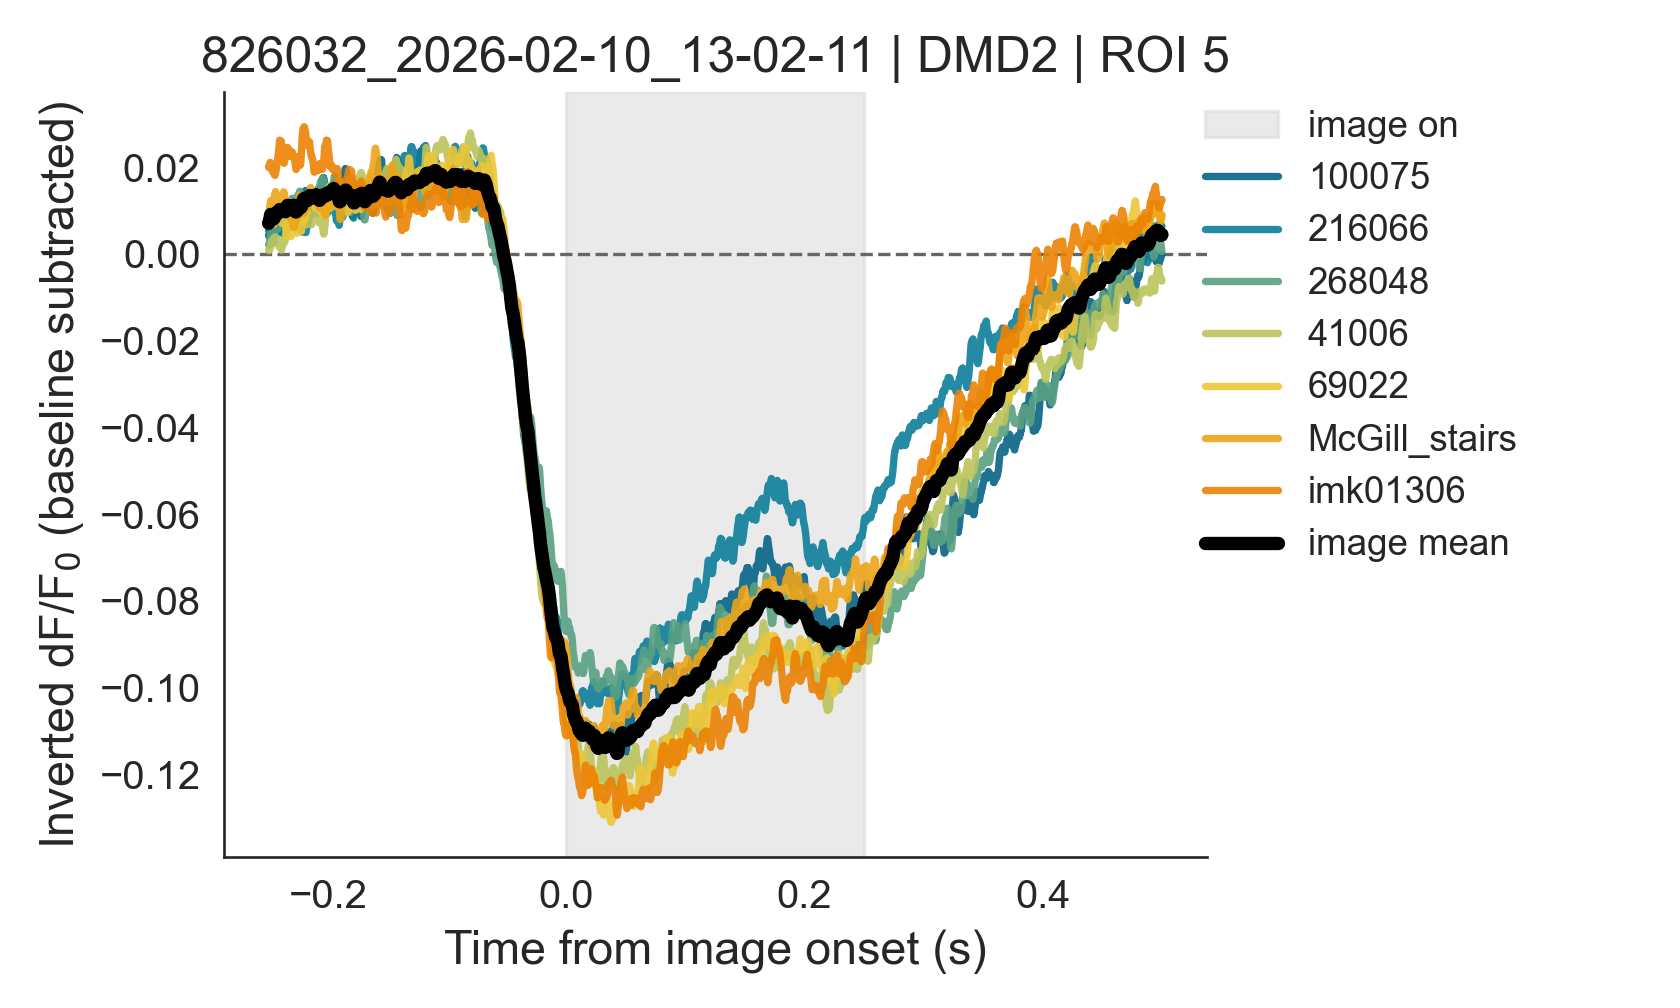

In [11]:

pkg = mean_packages[EXAMPLE_SESSION_ID]
dmd_data = pkg[f"DMD{EXAMPLE_DMD}"]
t = np.asarray(pkg["timebase_sec"]["image"], dtype=float)

fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.axvspan(0, 0.25, color="0.85", alpha=0.55, zorder=0, label="image on")

all_traces = []
for i, (stim_name, stim_data) in enumerate(dmd_data["image_identity"].items()):
    y = np.asarray(stim_data["mean"], dtype=float)[EXAMPLE_ROI_IDX]
    tt = t[: len(y)]
    yb = baseline_subtracted_trace(y, tt, IMAGE_BASELINE_WINDOW)
    all_traces.append(yb)
    ax.plot(tt, yb, color=IMAGE_COLORS[i % len(IMAGE_COLORS)], lw=2.2, alpha=0.9, label=stim_label(stim_name))

mean_trace = np.nanmean(np.vstack(all_traces), axis=0)
ax.plot(tt, mean_trace, color="black", lw=4.0, label="image mean")
ax.axhline(0, color="0.4", lw=1.0, ls="--", zorder=0)
ax.set_xlabel("Time from image onset (s)")
ax.set_ylabel("Inverted dF/F$_0$ (baseline subtracted)")
ax.set_title(f"{EXAMPLE_SESSION_ID} | DMD{EXAMPLE_DMD} | ROI {EXAMPLE_ROI_IDX}")
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.02), frameon=False)
clean_axes(ax)
fig.tight_layout()
maybe_savefig(fig, f"example_image_psth_{EXAMPLE_SESSION_ID}_DMD{EXAMPLE_DMD}_ROI{EXAMPLE_ROI_IDX}")

## Example: change and omission PSTHs for the same ROI

These are useful for visually comparing image-response, change-response, and omission-ramp phenotypes.

<IPython.core.display.Javascript object>


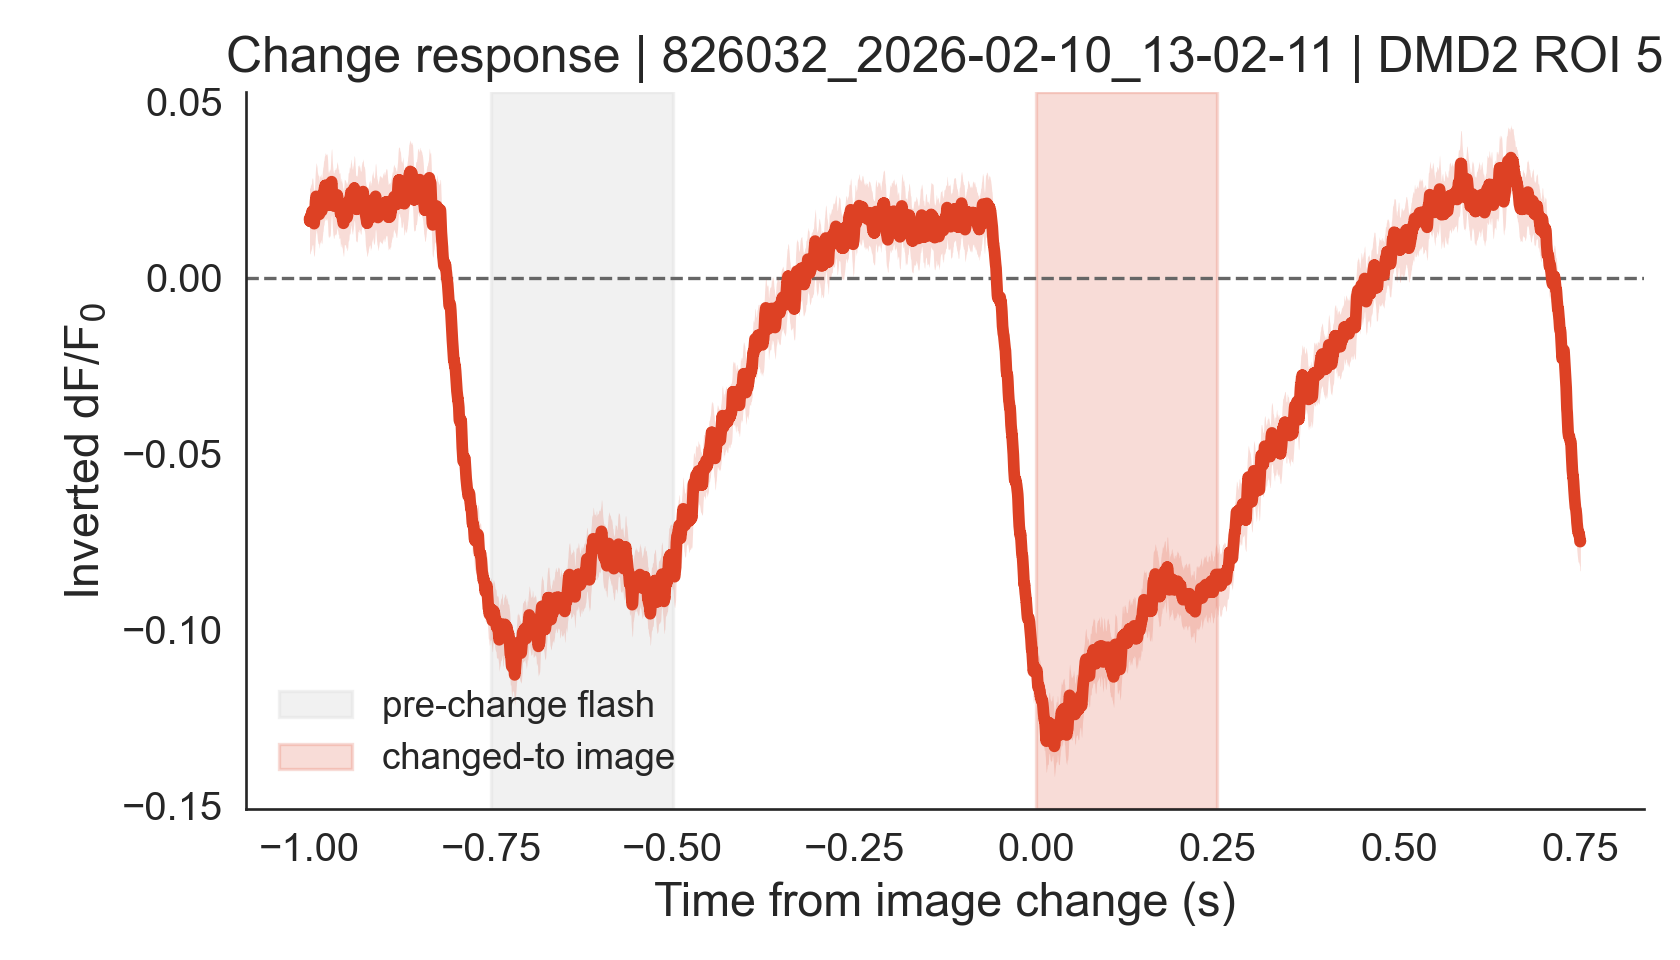

<IPython.core.display.Javascript object>


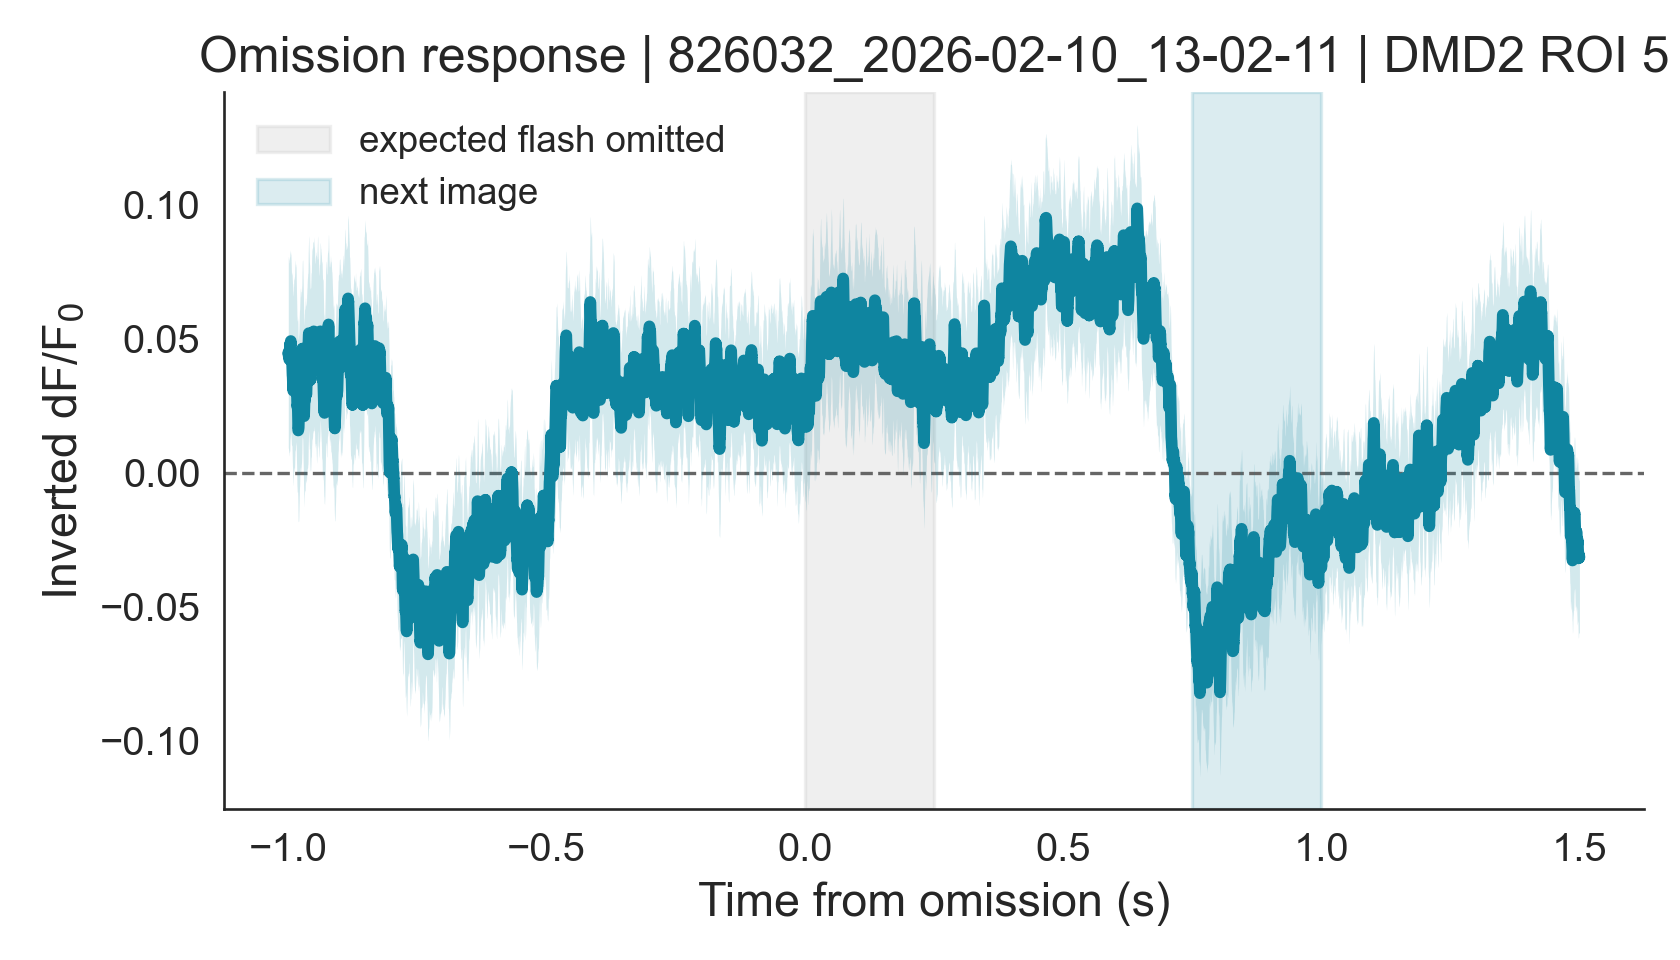

In [12]:

pkg = mean_packages[EXAMPLE_SESSION_ID]
dmd_data = pkg[f"DMD{EXAMPLE_DMD}"]

fig, ax = plt.subplots(figsize=(7.0, 4.0))
t_change = np.asarray(pkg["timebase_sec"]["change"], dtype=float)
y = np.asarray(dmd_data["change"]["mean"], dtype=float)[EXAMPLE_ROI_IDX]
y_std = np.asarray(dmd_data["change"].get("std", np.full_like(dmd_data["change"]["mean"], np.nan)), dtype=float)[EXAMPLE_ROI_IDX]
n = int(np.asarray(dmd_data["change"].get("n_events", np.nan)).squeeze())
tt = t_change[: len(y)]
yb = baseline_subtracted_trace(y, tt, CHANGE_BASELINE_WINDOW)
sem = y_std / np.sqrt(max(n, 1))

ax.axvspan(-0.75, -0.50, color="0.88", alpha=0.45, zorder=0, label="pre-change flash")
ax.axvspan(0.00, 0.25, color="#dd4124", alpha=0.18, zorder=0, label="changed-to image")
ax.plot(tt, yb, color="#dd4124", lw=3.5)
ax.fill_between(tt, yb - sem, yb + sem, color="#dd4124", alpha=0.18, lw=0)
ax.axhline(0, color="0.4", lw=1.0, ls="--", zorder=0)
ax.set_xlabel("Time from image change (s)")
ax.set_ylabel("Inverted dF/F$_0$")
ax.set_title(f"Change response | {EXAMPLE_SESSION_ID} | DMD{EXAMPLE_DMD} ROI {EXAMPLE_ROI_IDX}")
ax.legend(frameon=False)
clean_axes(ax)
fig.tight_layout()
maybe_savefig(fig, f"example_change_psth_{EXAMPLE_SESSION_ID}_DMD{EXAMPLE_DMD}_ROI{EXAMPLE_ROI_IDX}")

fig, ax = plt.subplots(figsize=(7.0, 4.0))
t_om = np.asarray(pkg["timebase_sec"]["omission"], dtype=float)
y = np.asarray(dmd_data["omission"]["mean"], dtype=float)[EXAMPLE_ROI_IDX]
y_std = np.asarray(dmd_data["omission"].get("std", np.full_like(dmd_data["omission"]["mean"], np.nan)), dtype=float)[EXAMPLE_ROI_IDX]
n = int(np.asarray(dmd_data["omission"].get("n_events", np.nan)).squeeze())
tt = t_om[: len(y)]
yb = baseline_subtracted_trace(y, tt, OMISSION_BASELINE_WINDOW)
sem = y_std / np.sqrt(max(n, 1))

ax.axvspan(0.00, 0.25, color="0.7", alpha=0.20, zorder=0, label="expected flash omitted")
ax.axvspan(0.75, 1.00, color="#0f85a0", alpha=0.15, zorder=0, label="next image")
ax.plot(tt, yb, color="#0f85a0", lw=3.5)
ax.fill_between(tt, yb - sem, yb + sem, color="#0f85a0", alpha=0.18, lw=0)
ax.axhline(0, color="0.4", lw=1.0, ls="--", zorder=0)
ax.set_xlabel("Time from omission (s)")
ax.set_ylabel("Inverted dF/F$_0$")
ax.set_title(f"Omission response | {EXAMPLE_SESSION_ID} | DMD{EXAMPLE_DMD} ROI {EXAMPLE_ROI_IDX}")
ax.legend(frameon=False)
clean_axes(ax)
fig.tight_layout()
maybe_savefig(fig, f"example_omission_psth_{EXAMPLE_SESSION_ID}_DMD{EXAMPLE_DMD}_ROI{EXAMPLE_ROI_IDX}")

## ROI × time heatmap of mean image response

This plot is useful for visually discovering response classes and depth differences without committing to the classification thresholds.

<IPython.core.display.Javascript object>


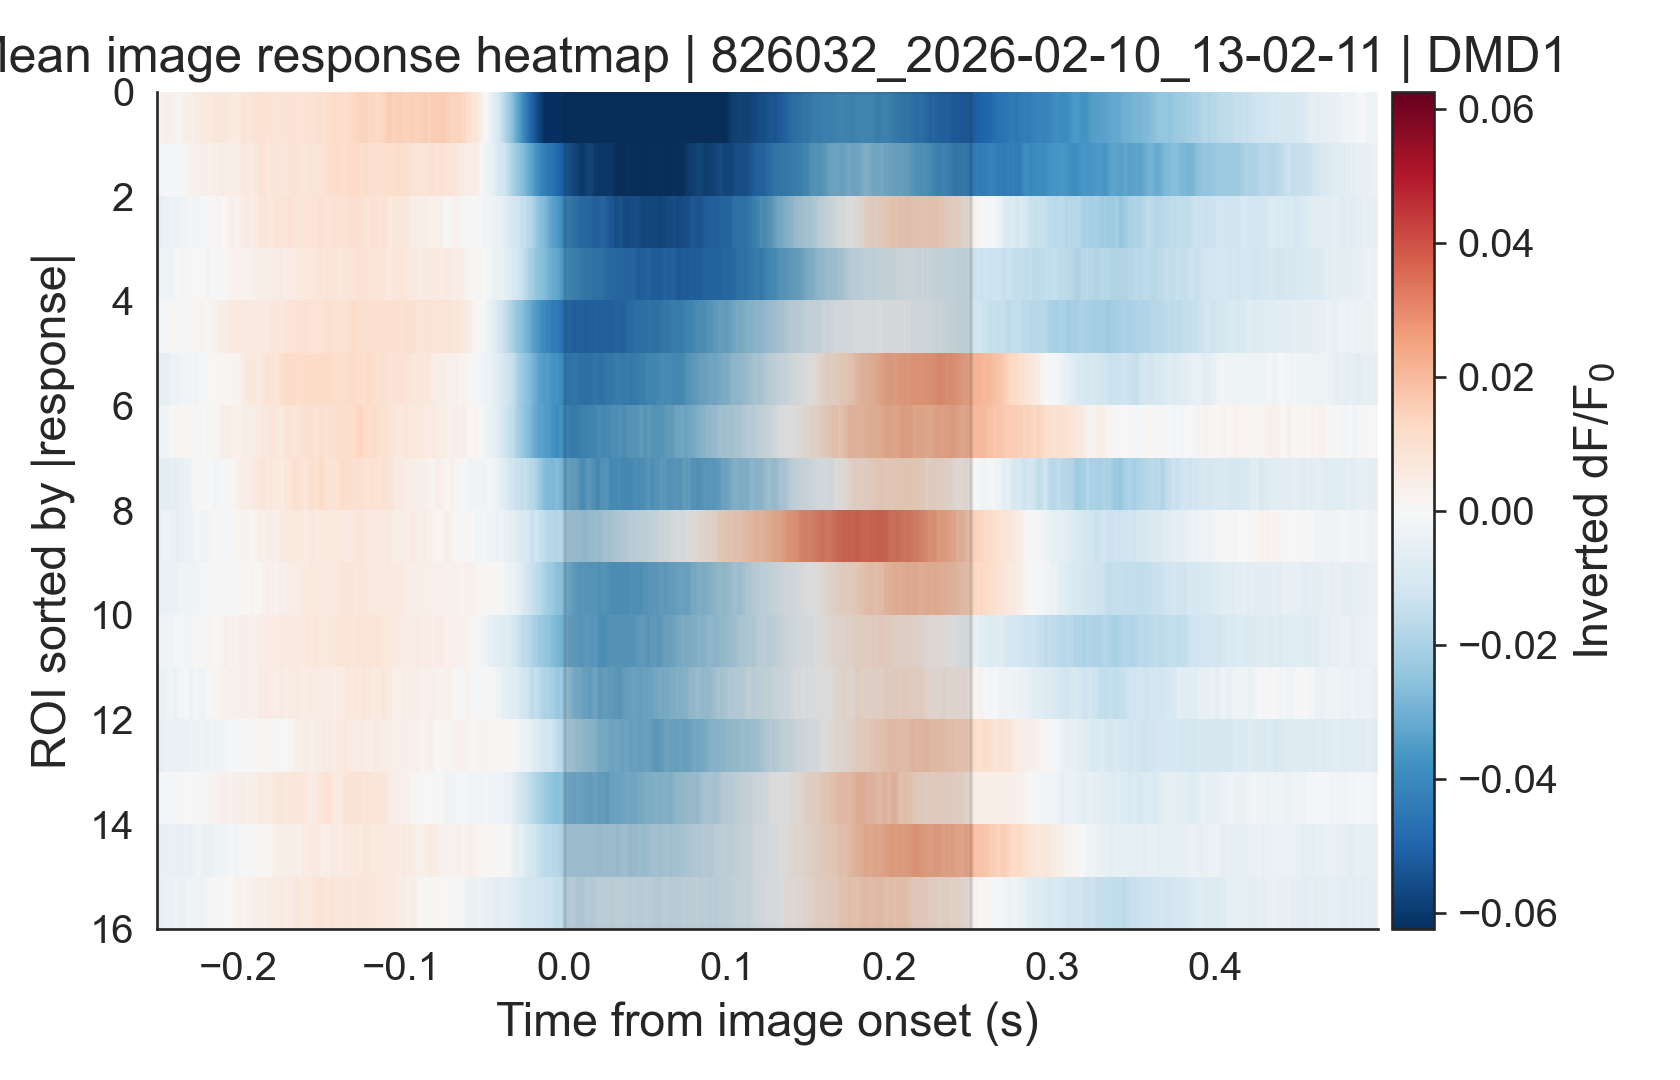

<IPython.core.display.Javascript object>


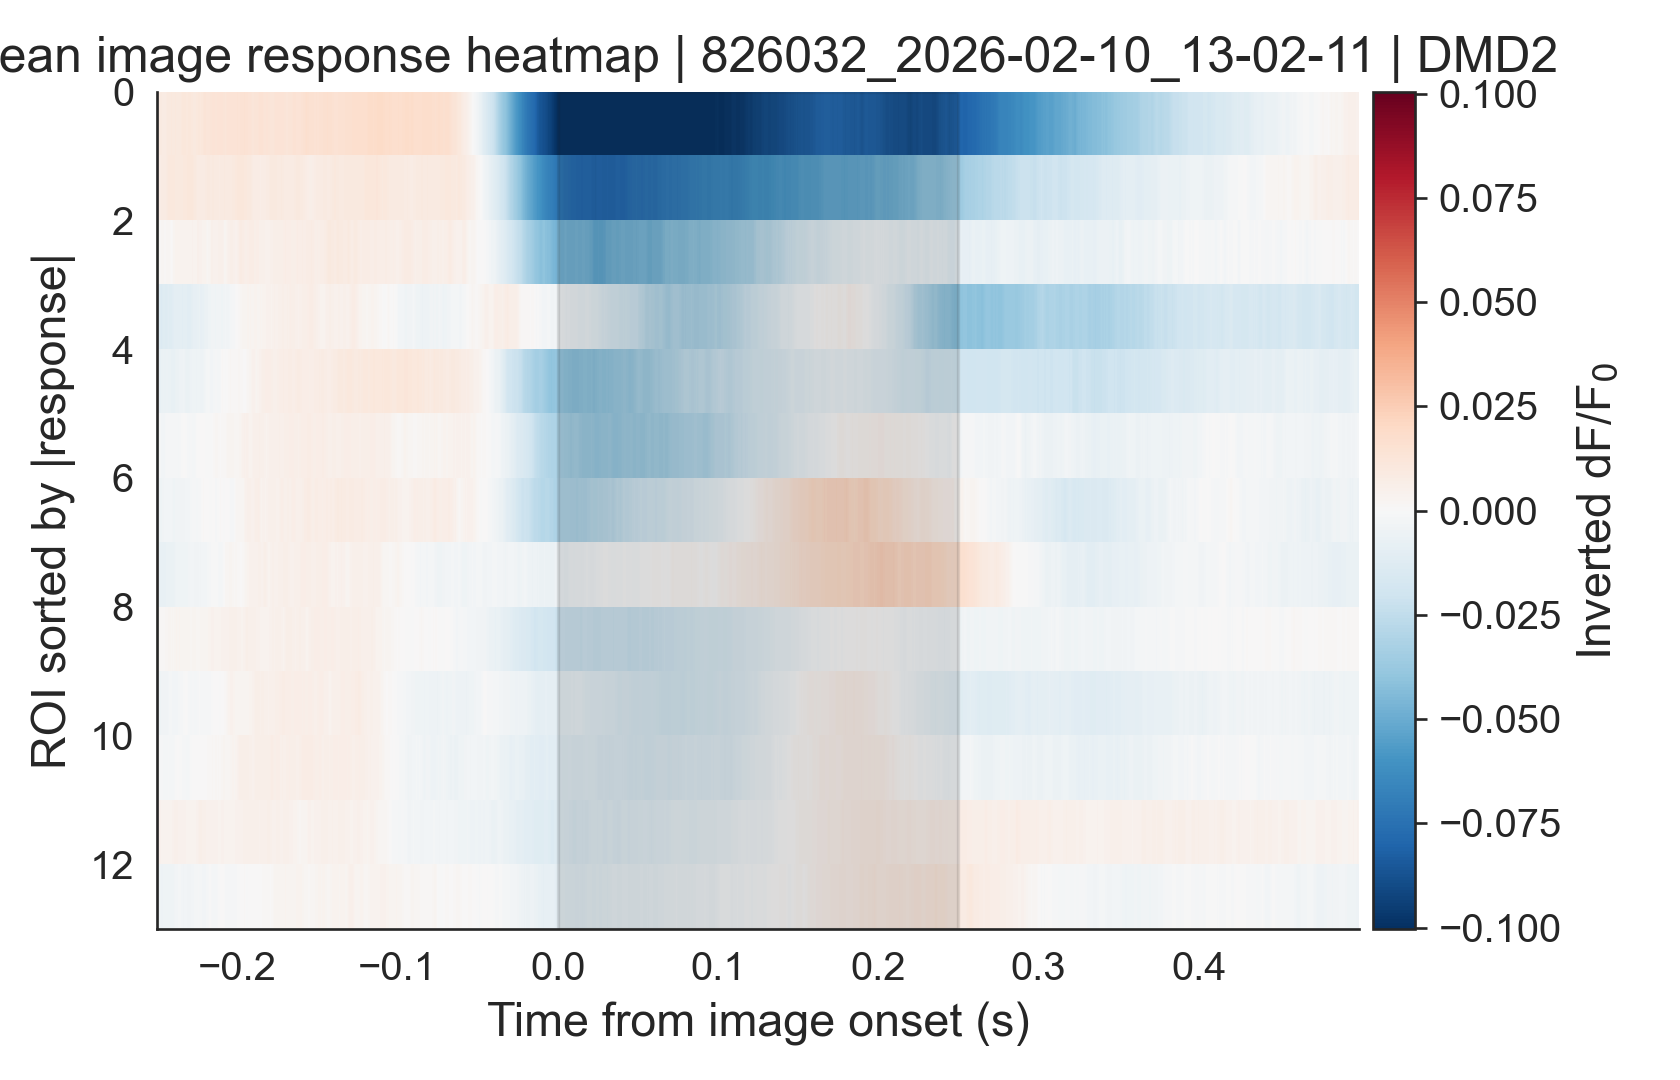

In [13]:

pkg = mean_packages[EXAMPLE_SESSION_ID]
t = np.asarray(pkg["timebase_sec"]["image"], dtype=float)

for dmd in [1, 2]:
    dmd_key = f"DMD{dmd}"
    if dmd_key not in pkg:
        continue
    dmd_data = pkg[dmd_key]
    roi_ids = dmd_data.get("roi_ids", [])
    if len(roi_ids) == 0:
        continue

    traces = []
    for roi_idx in range(len(roi_ids)):
        per_image = []
        for stim_name, stim_data in dmd_data["image_identity"].items():
            y = np.asarray(stim_data["mean"], dtype=float)[roi_idx]
            tt = t[: len(y)]
            per_image.append(baseline_subtracted_trace(y, tt, IMAGE_BASELINE_WINDOW))
        traces.append(np.nanmean(np.vstack(per_image), axis=0))
    X = np.vstack(traces)
    # Sort by peak response time and polarity for visual structure.
    peak_abs = np.nanmax(np.abs(X[:, time_mask(tt, IMAGE_FULL_RESPONSE_WINDOW)]), axis=1)
    order = np.argsort(-peak_abs)

    vmax = np.nanpercentile(np.abs(X), 99)
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    im = ax.imshow(
        X[order],
        aspect="auto",
        interpolation="nearest",
        extent=[tt[0], tt[-1], len(order), 0],
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
    )
    ax.axvspan(0, 0.25, color="0.1", alpha=0.12, zorder=2)
    ax.set_xlabel("Time from image onset (s)")
    ax.set_ylabel("ROI sorted by |response|")
    ax.set_title(f"Mean image response heatmap | {EXAMPLE_SESSION_ID} | DMD{dmd}")
    cbar = fig.colorbar(im, ax=ax, pad=0.01)
    cbar.set_label("Inverted dF/F$_0$")
    clean_axes(ax)
    fig.tight_layout()
    maybe_savefig(fig, f"image_heatmap_{EXAMPLE_SESSION_ID}_DMD{dmd}")

# Summary plots: image response class, image-response magnitude, and image identity structure

,session_type,depth_um,response_class,n,fraction
0,familiar,50,no_change,211,1.000000
1,familiar,250,no_change,160,1.000000
2,novel,50,no_change,24,0.827586
3,novel,50,suppressed,5,0.172414
4,novel,250,no_change,19,0.826087


<IPython.core.display.Javascript object>


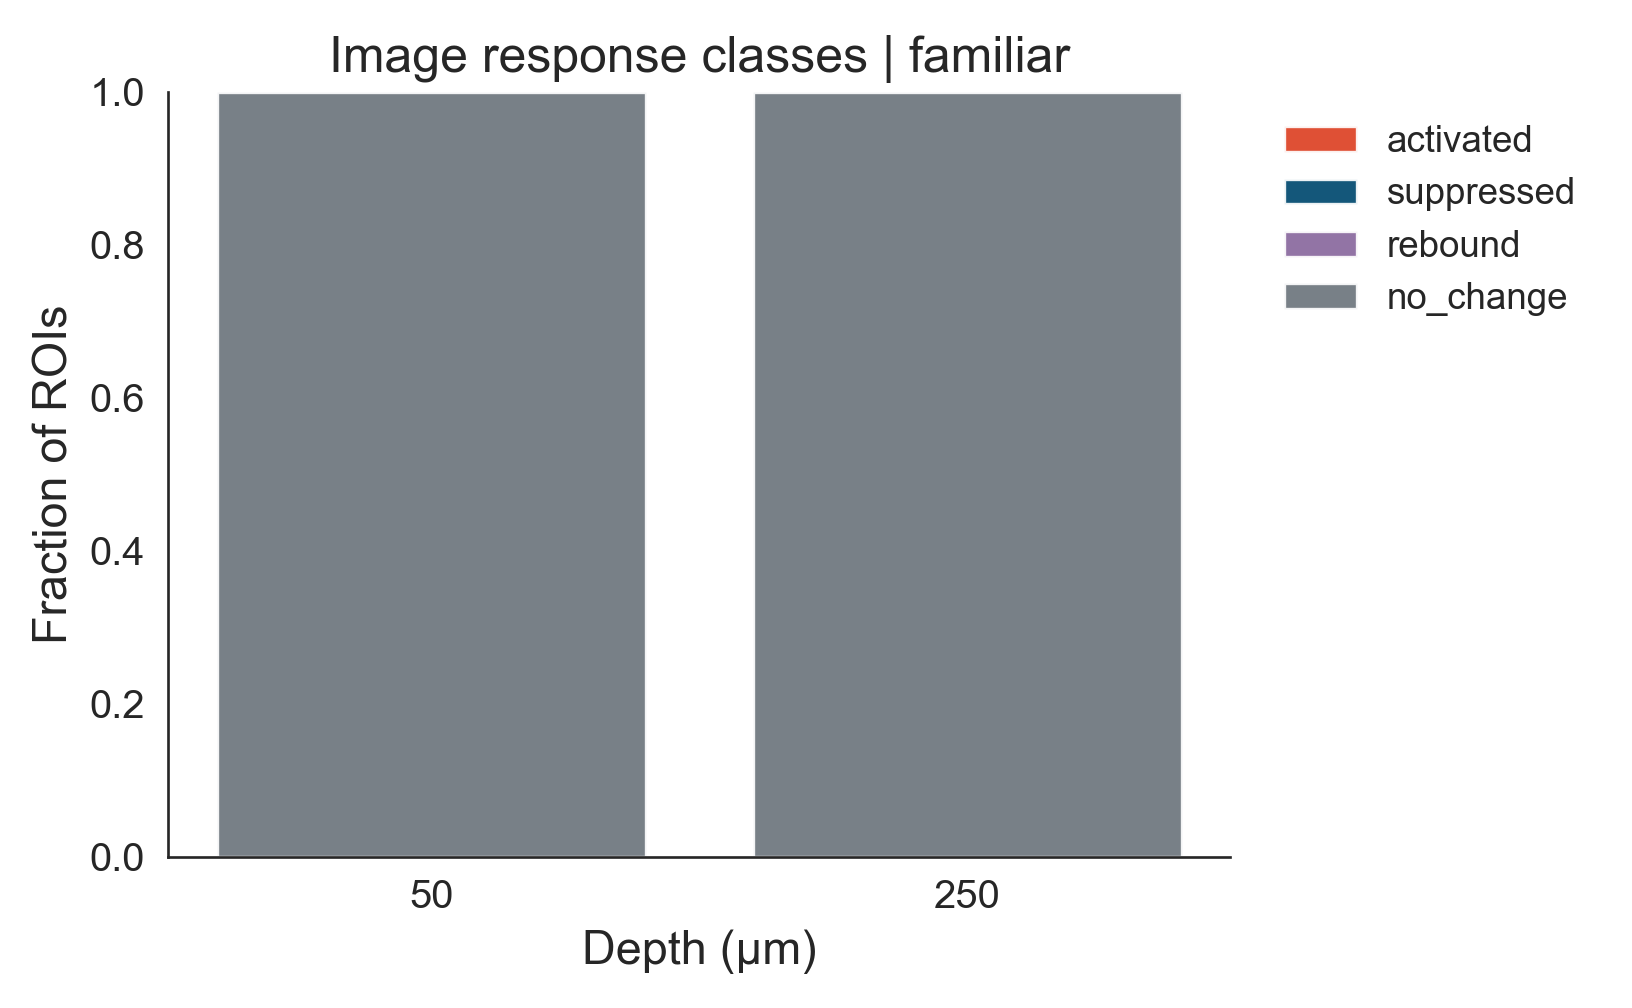

<IPython.core.display.Javascript object>


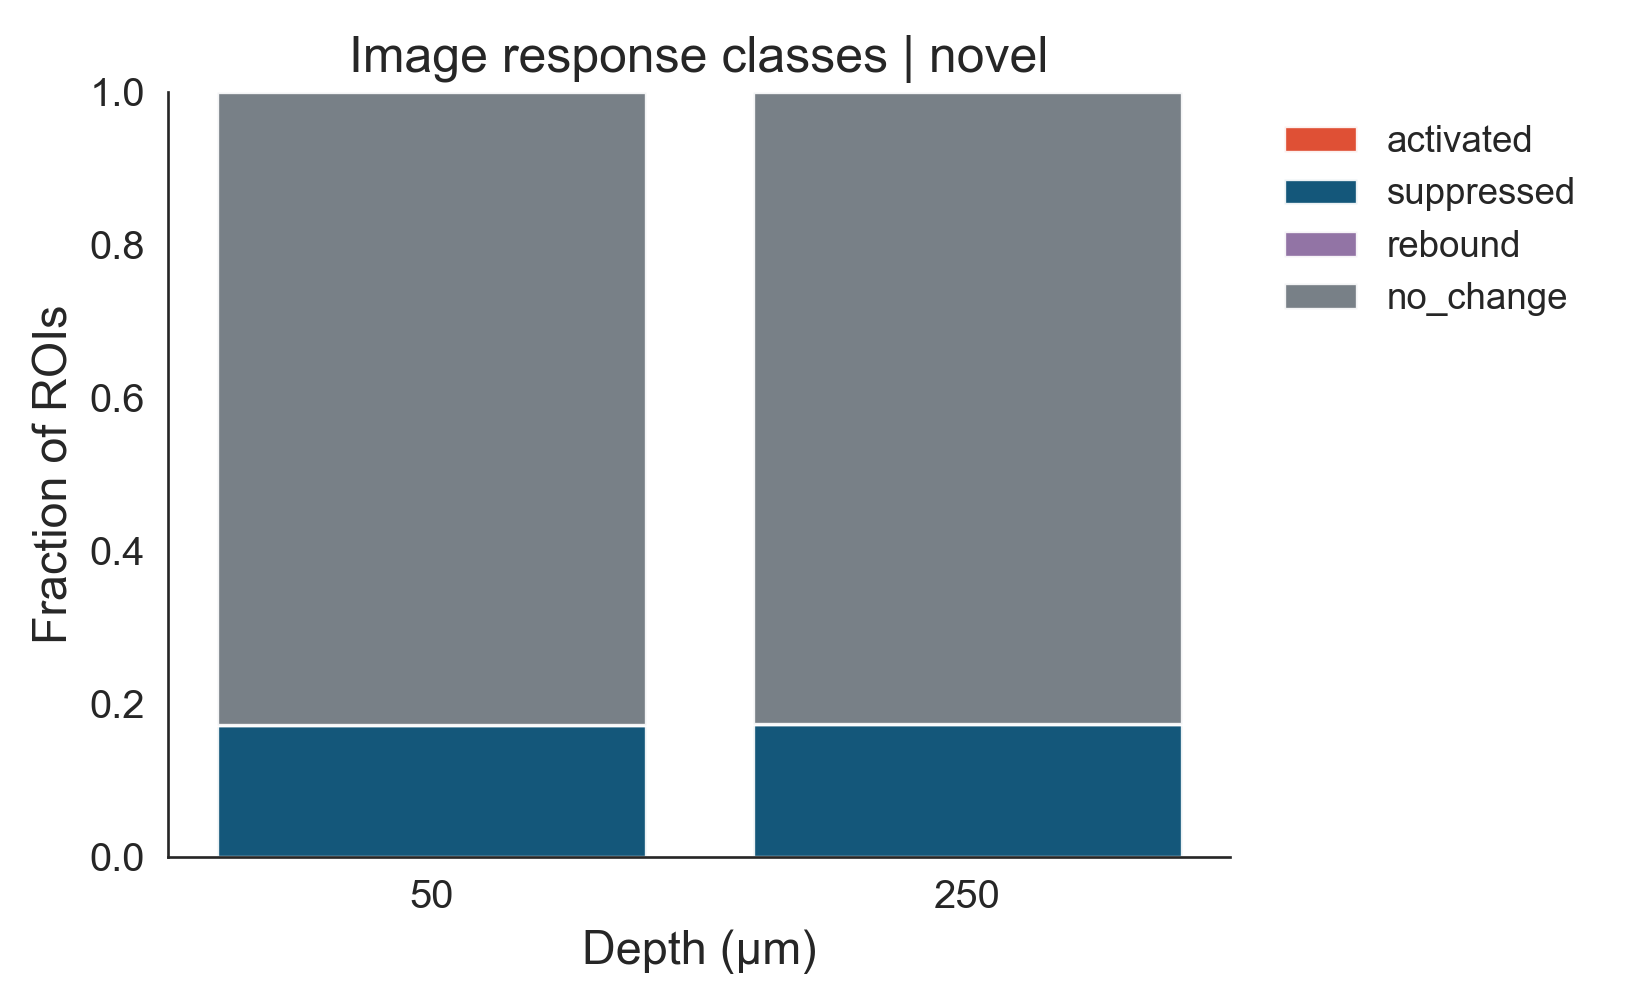

<IPython.core.display.Javascript object>


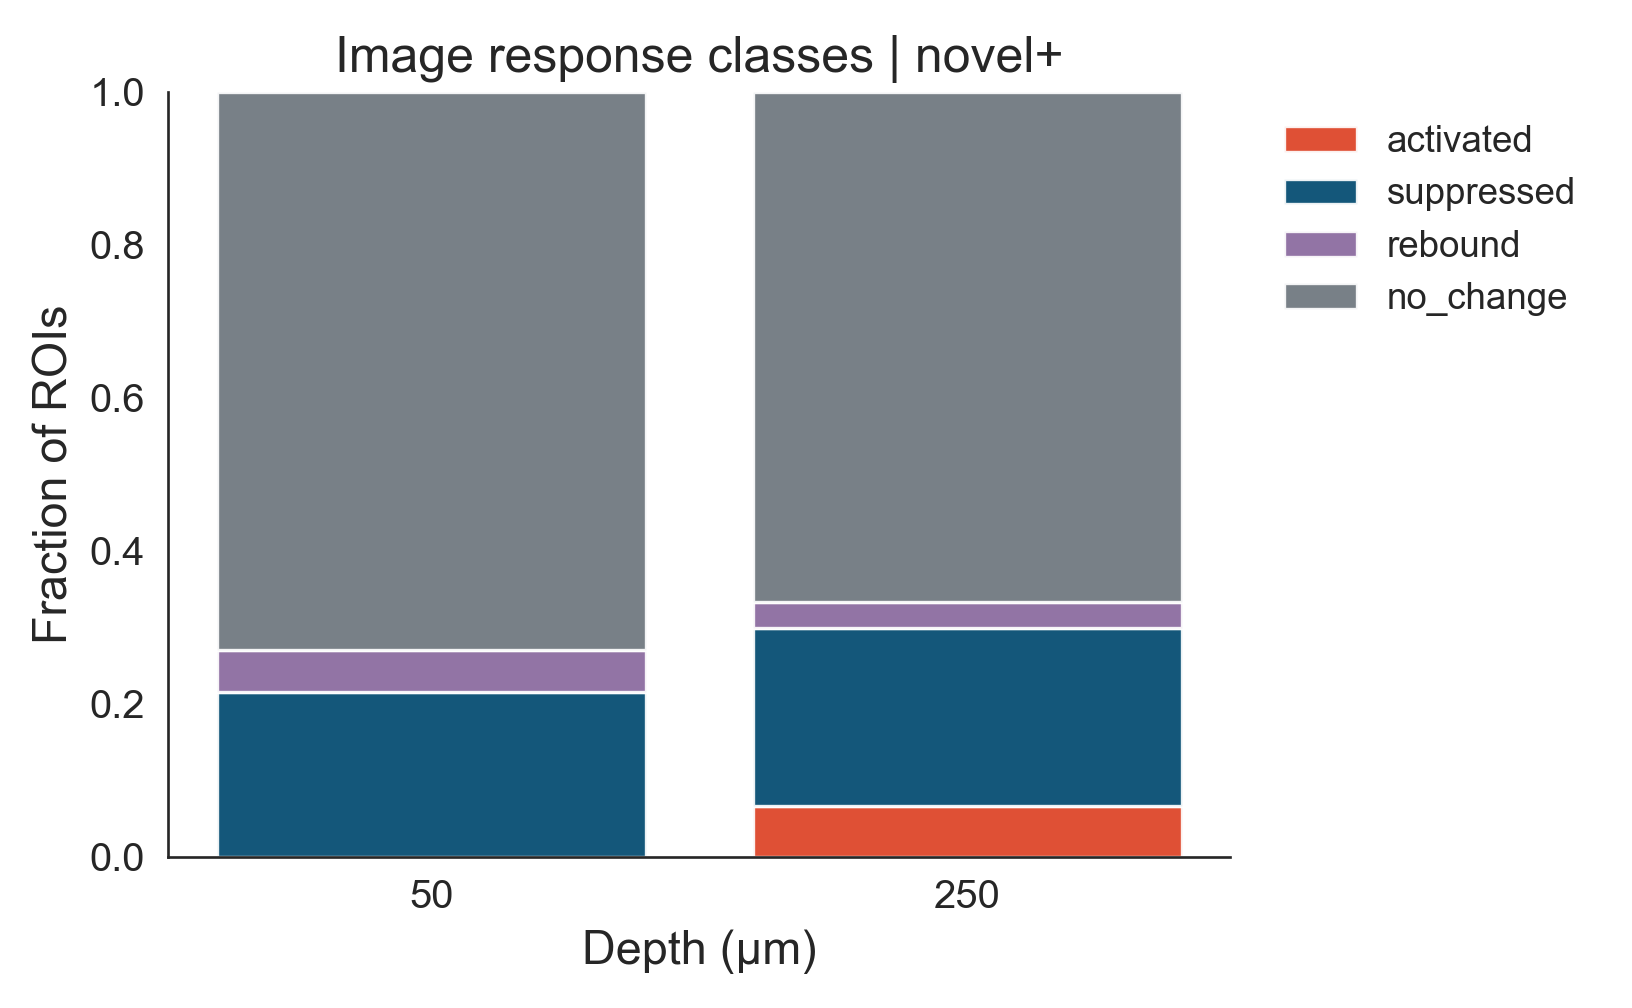

In [14]:

# Fraction of response classes by depth and session type.
if len(roi_response_summary):
    class_counts = (
        roi_response_summary
        .groupby(["session_type", "depth_um", "response_class"], dropna=False)
        .size()
        .rename("n")
        .reset_index()
    )
    totals = class_counts.groupby(["session_type", "depth_um"], dropna=False)["n"].transform("sum")
    class_counts["fraction"] = class_counts["n"] / totals
    display(class_counts.head())

    session_types = list(pd.unique(class_counts["session_type"]))
    classes = [c for c in CLASS_COLORS.keys() if c in set(class_counts["response_class"])]

    for session_type in session_types:
        sub = class_counts.loc[class_counts["session_type"].eq(session_type)].copy()
        depths = sorted(sub["depth_um"].dropna().unique())
        x = np.arange(len(depths))
        bottom = np.zeros(len(depths), dtype=float)

        fig, ax = plt.subplots(figsize=(6.8, 4.2))
        for cls in classes:
            y = []
            for depth in depths:
                v = sub.loc[sub["depth_um"].eq(depth) & sub["response_class"].eq(cls), "fraction"]
                y.append(float(v.iloc[0]) if len(v) else 0.0)
            ax.bar(x, y, bottom=bottom, color=CLASS_COLORS.get(cls, "0.5"), label=cls, alpha=0.92)
            bottom += np.asarray(y)
        ax.set_xticks(x)
        ax.set_xticklabels([f"{d:g}" for d in depths])
        ax.set_ylim(0, 1)
        ax.set_xlabel("Depth (µm)")
        ax.set_ylabel("Fraction of ROIs")
        ax.set_title(f"Image response classes | {session_type}")
        ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
        clean_axes(ax)
        fig.tight_layout()
        maybe_savefig(fig, f"response_class_fraction_{session_type}")

<IPython.core.display.Javascript object>


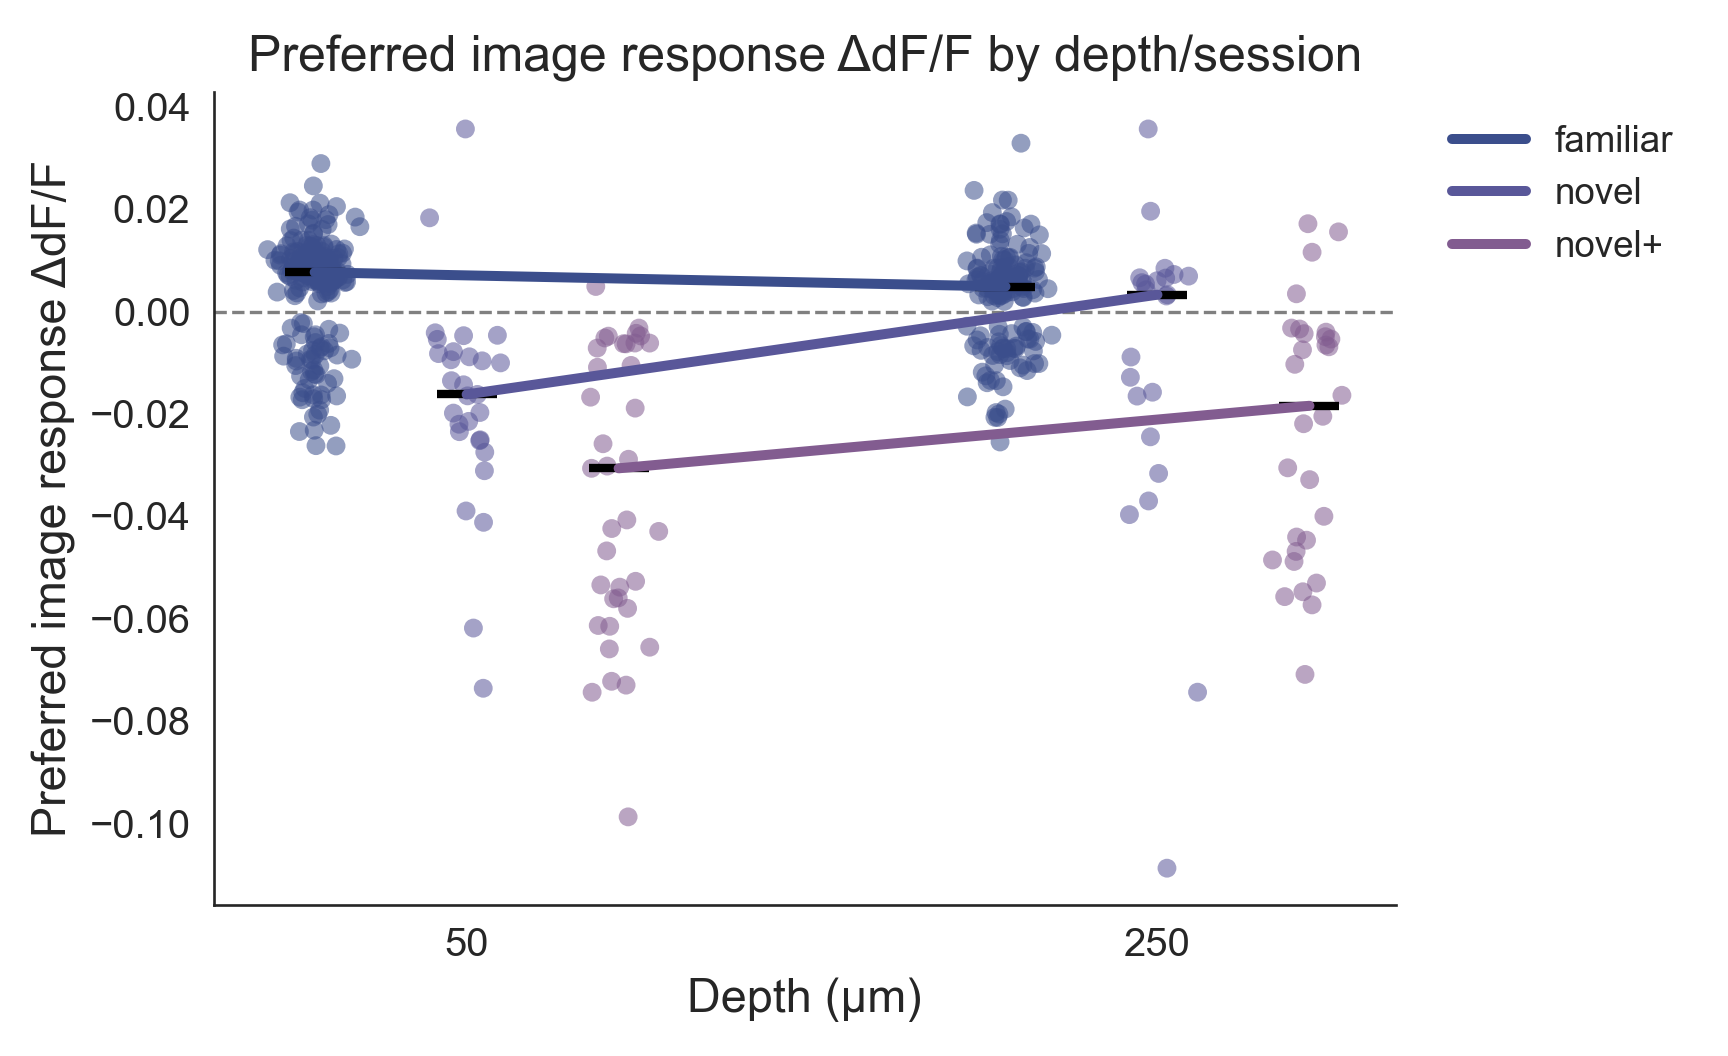

<IPython.core.display.Javascript object>


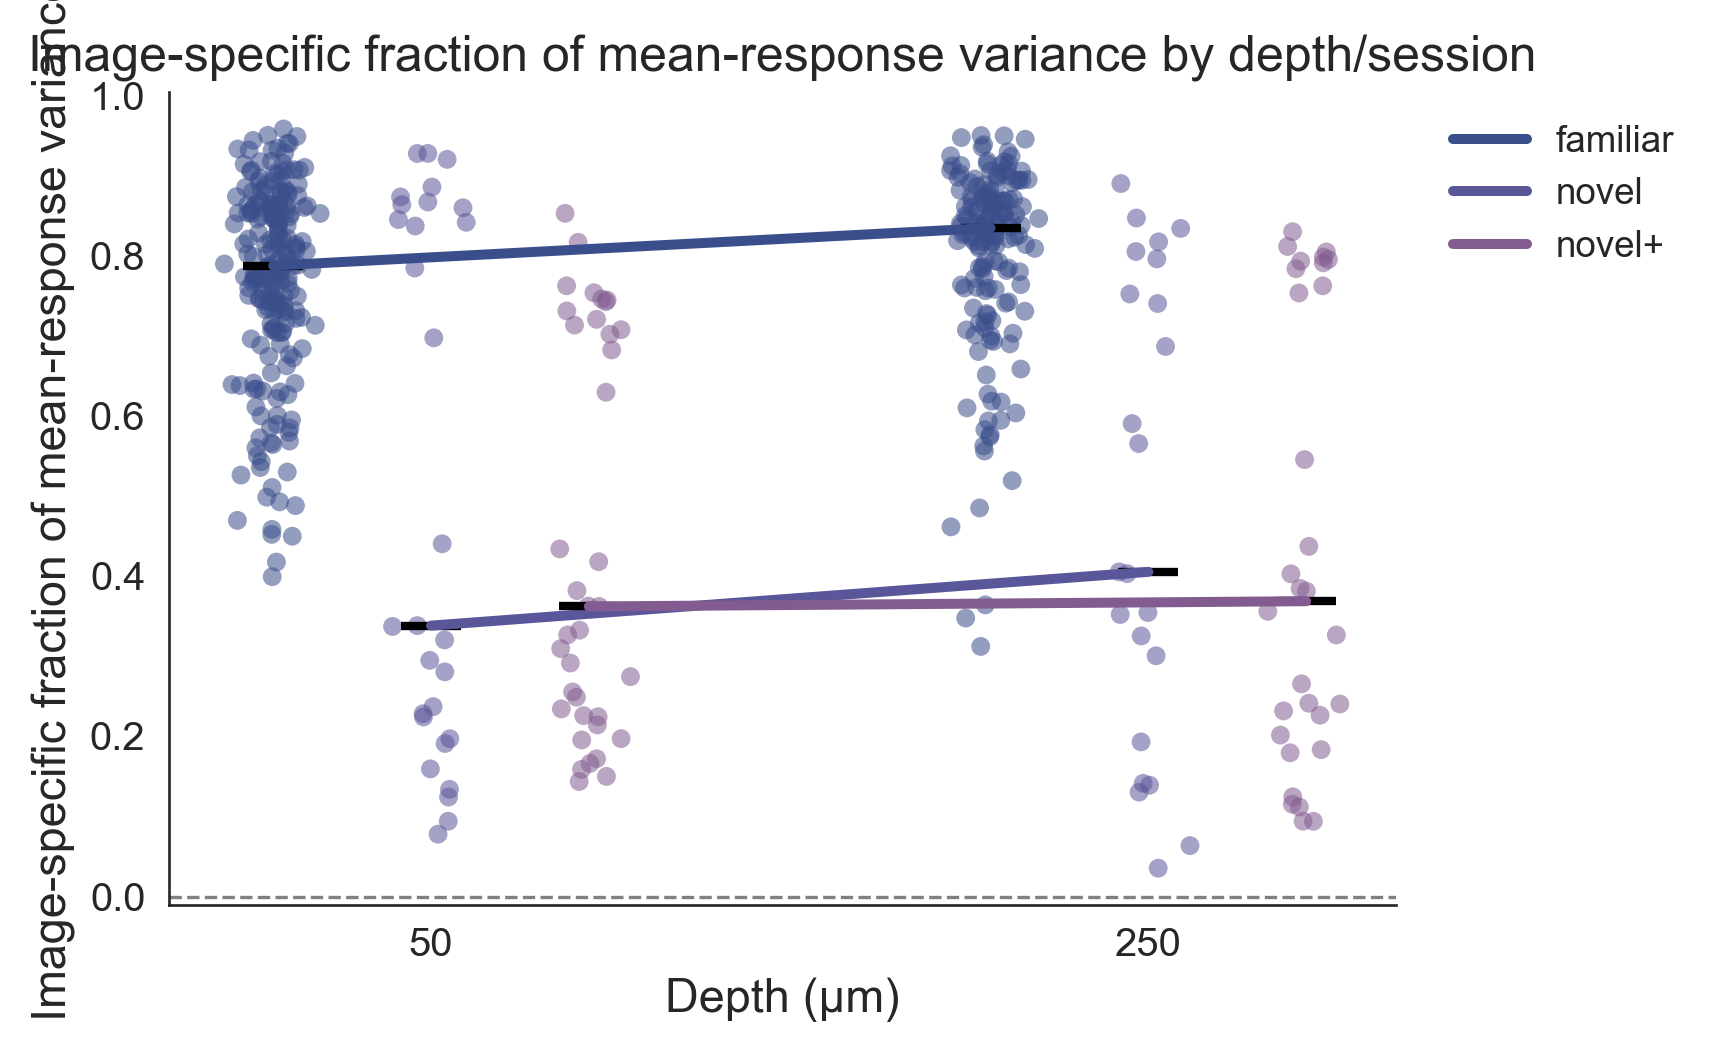

<IPython.core.display.Javascript object>


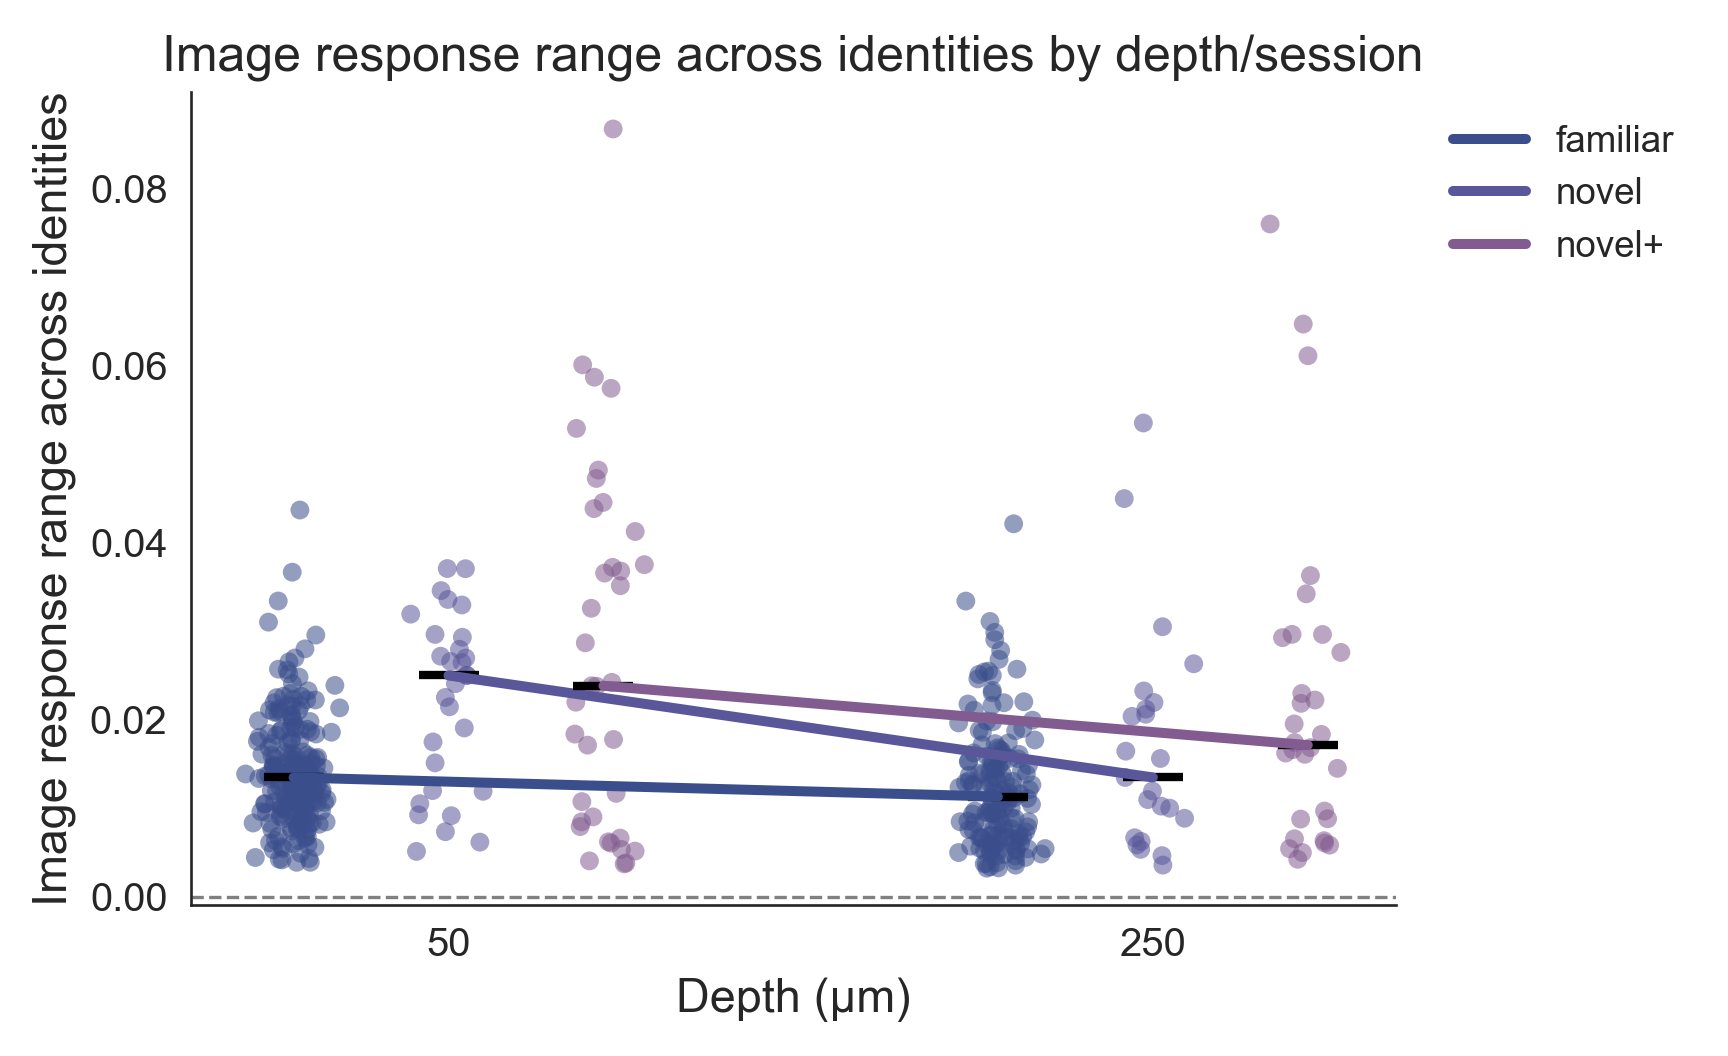

In [15]:

# Response magnitude and image-identity deviation fraction by depth/session.
if len(roi_response_summary):
    metrics_to_plot = [
        ("preferred_abs_stim_delta", "Preferred image response ΔdF/F"),
        ("identity_deviation_fraction", "Image-specific fraction of mean-response variance"),
        ("range_stim_delta_across_images", "Image response range across identities"),
    ]

    for metric, ylabel in metrics_to_plot:
        fig, ax = plt.subplots(figsize=(7.2, 4.4))
        x_categories = sorted(roi_response_summary["depth_um"].dropna().unique())
        session_types = list(pd.unique(roi_response_summary["session_type"]))
        offsets = np.linspace(-0.22, 0.22, max(len(session_types), 1))
        for j, session_type in enumerate(session_types):
            sub = roi_response_summary.loc[roi_response_summary["session_type"].eq(session_type)]
            color = SESSION_COLORS[j % len(SESSION_COLORS)]
            for i, depth in enumerate(x_categories):
                vals = sub.loc[sub["depth_um"].eq(depth), metric].to_numpy(dtype=float)
                vals = vals[np.isfinite(vals)]
                if vals.size == 0:
                    continue
                rng = np.random.default_rng(12345 + i + j)
                jitter = rng.normal(0, 0.025, size=vals.size)
                ax.scatter(np.full(vals.size, i + offsets[j]) + jitter, vals, color=color, alpha=0.55, s=32, edgecolor="none")
                ax.plot(i + offsets[j], np.nanmedian(vals), marker="_", markersize=18, color="black", mew=2.5)
            # Connect median across depths for this session type.
            med = [np.nanmedian(sub.loc[sub["depth_um"].eq(depth), metric].to_numpy(dtype=float)) for depth in x_categories]
            ax.plot(np.arange(len(x_categories)) + offsets[j], med, color=color, lw=3.0, label=str(session_type))
        ax.axhline(0, color="0.5", lw=1.0, ls="--", zorder=0)
        ax.set_xticks(np.arange(len(x_categories)))
        ax.set_xticklabels([f"{d:g}" for d in x_categories])
        ax.set_xlabel("Depth (µm)")
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel + " by depth/session")
        ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
        clean_axes(ax)
        fig.tight_layout()
        maybe_savefig(fig, f"summary_{metric}_by_depth_session")

# Change and omission event metrics

These are deliberately simple first-pass metrics. They can be refined after inspection.

- `change_target_delta`: changed-to image window minus pre-change baseline.
- `change_extra_delta`: changed-to image response minus response to the preceding pre-change flash window.
- `omission_ramp_delta`: omission ramp window minus pre-omission baseline.
- `omission_expected_delta`: activity during the expected-but-omitted flash window minus baseline.

In [16]:

def compute_event_response_table(mean_packages):
    rows = []
    for session_id, pkg in mean_packages.items():
        meta = package_session_metadata(session_id)
        for dmd_name in [k for k in pkg.keys() if str(k).startswith("DMD")]:
            dmd = int(str(dmd_name).replace("DMD", ""))
            dmd_data = pkg[dmd_name]
            roi_ids = [str(x) for x in dmd_data.get("roi_ids", [])]
            depth = meta.get(f"dmd{dmd}_depth", np.nan)
            for event_name in ["change", "omission"]:
                if event_name not in dmd_data or event_name not in pkg["timebase_sec"]:
                    continue
                t = np.asarray(pkg["timebase_sec"][event_name], dtype=float)
                arr = np.asarray(dmd_data[event_name]["mean"], dtype=float)
                std_arr = np.asarray(dmd_data[event_name].get("std", np.full_like(arr, np.nan)), dtype=float)
                n_events = int(np.asarray(dmd_data[event_name].get("n_events", np.nan)).squeeze())
                tt = t[: arr.shape[1]]
                for roi_idx, roi_id in enumerate(roi_ids):
                    y = arr[roi_idx]
                    std_y = std_arr[roi_idx]
                    base_window = CHANGE_BASELINE_WINDOW if event_name == "change" else OMISSION_BASELINE_WINDOW
                    yb = baseline_subtracted_trace(y, tt, base_window)

                    if event_name == "change":
                        target_delta = response_scalar(y, tt, CHANGE_TARGET_WINDOW, CHANGE_BASELINE_WINDOW)
                        prechange_delta = response_scalar(y, tt, CHANGE_PRECHANGE_FLASH_WINDOW, CHANGE_BASELINE_WINDOW)
                        post_delta = response_scalar(y, tt, CHANGE_POST_WINDOW, CHANGE_BASELINE_WINDOW)
                        peak_pos, t_peak_pos = window_peak(yb, tt, (0.0, 0.75), mode="max")
                        peak_neg, t_peak_neg = window_peak(yb, tt, (0.0, 0.75), mode="min")
                        z = delta_zscore(y, std_y, n_events, tt, CHANGE_TARGET_WINDOW, CHANGE_BASELINE_WINDOW)
                        rows.append({
                            "session_id": session_id,
                            "subject_id": meta.get("subject_id", pkg.get("metadata", {}).get("subject_id", np.nan)),
                            "session_number": meta.get("session_#", meta.get("session_number", np.nan)),
                            "session_type": meta.get("session_type", "unknown"),
                            "stimulus_set": meta.get("stimulus", "unknown"),
                            "dmd": dmd,
                            "depth_um": depth,
                            "roi_idx": roi_idx,
                            "roi_id": roi_id,
                            "event_type": event_name,
                            "n_events": n_events,
                            "event_delta": target_delta,
                            "pre_event_delta": prechange_delta,
                            "post_event_delta": post_delta,
                            "change_extra_delta": target_delta - prechange_delta,
                            "peak_positive": peak_pos,
                            "t_peak_positive": t_peak_pos,
                            "peak_negative": peak_neg,
                            "t_peak_negative": t_peak_neg,
                            "z_event": z,
                        })
                    else:
                        expected_delta = response_scalar(y, tt, OMISSION_EXPECTED_FLASH_WINDOW, OMISSION_BASELINE_WINDOW)
                        ramp_delta = response_scalar(y, tt, OMISSION_RAMP_WINDOW, OMISSION_BASELINE_WINDOW)
                        next_flash_delta = response_scalar(y, tt, OMISSION_NEXT_FLASH_WINDOW, OMISSION_BASELINE_WINDOW)
                        peak_pos, t_peak_pos = window_peak(yb, tt, (0.0, 1.0), mode="max")
                        peak_neg, t_peak_neg = window_peak(yb, tt, (0.0, 1.0), mode="min")
                        z = delta_zscore(y, std_y, n_events, tt, OMISSION_RAMP_WINDOW, OMISSION_BASELINE_WINDOW)
                        rows.append({
                            "session_id": session_id,
                            "subject_id": meta.get("subject_id", pkg.get("metadata", {}).get("subject_id", np.nan)),
                            "session_number": meta.get("session_#", meta.get("session_number", np.nan)),
                            "session_type": meta.get("session_type", "unknown"),
                            "stimulus_set": meta.get("stimulus", "unknown"),
                            "dmd": dmd,
                            "depth_um": depth,
                            "roi_idx": roi_idx,
                            "roi_id": roi_id,
                            "event_type": event_name,
                            "n_events": n_events,
                            "event_delta": ramp_delta,
                            "expected_flash_delta": expected_delta,
                            "ramp_delta": ramp_delta,
                            "next_flash_delta": next_flash_delta,
                            "peak_positive": peak_pos,
                            "t_peak_positive": t_peak_pos,
                            "peak_negative": peak_neg,
                            "t_peak_negative": t_peak_neg,
                            "z_event": z,
                        })
    return pd.DataFrame(rows)


event_response_df = compute_event_response_table(mean_packages)
print("event_response_df", event_response_df.shape)
display(event_response_df.head())

if SAVE_TABLES and len(event_response_df):
    try:
        table_dir = SAVE_PATH / "tables"
        table_dir.mkdir(parents=True, exist_ok=True)
        event_response_df.to_csv(table_dir / f"{today_str}_asap7_change_omission_response_summary.csv", index=False)
    except Exception as exc:
        print(f"Could not save event table: {exc}")

event_response_df (980, 23)


,session_id,subject_id,session_number,session_type,stimulus_set,dmd,depth_um,roi_idx,roi_id,event_type,...,post_event_delta,change_extra_delta,peak_positive,t_peak_positive,peak_negative,t_peak_negative,z_event,expected_flash_delta,ramp_delta,next_flash_delta
0,826031_2026-01-30_15-04-02,826031,2,familiar,images_A,1,50,0,DMD1_roi0000,change,...,-0.003456,-0.010159,0.010939,0.060012,-0.015367,0.672271,0.099776,NaN,NaN,NaN
1,826031_2026-01-30_15-04-02,826031,2,familiar,images_A,1,50,1,DMD1_roi0001,change,...,0.000947,-0.008207,0.012097,0.336338,-0.010739,0.676669,0.157241,NaN,NaN,NaN
2,826031_2026-01-30_15-04-02,826031,2,familiar,images_A,1,50,2,DMD1_roi0002,change,...,0.002706,-0.008210,0.014800,0.134872,-0.010285,0.691079,0.345690,NaN,NaN,NaN
3,826031_2026-01-30_15-04-02,826031,2,familiar,images_A,1,50,3,DMD1_roi0003,change,...,0.001726,-0.007949,0.010525,0.374329,-0.008773,0.676575,0.279713,NaN,NaN,NaN
4,826031_2026-01-30_15-04-02,826031,2,familiar,images_A,1,50,4,DMD1_roi0004,change,...,0.002537,-0.009655,0.013876,0.365814,-0.007640,0.664972,0.329276,NaN,NaN,NaN


<IPython.core.display.Javascript object>


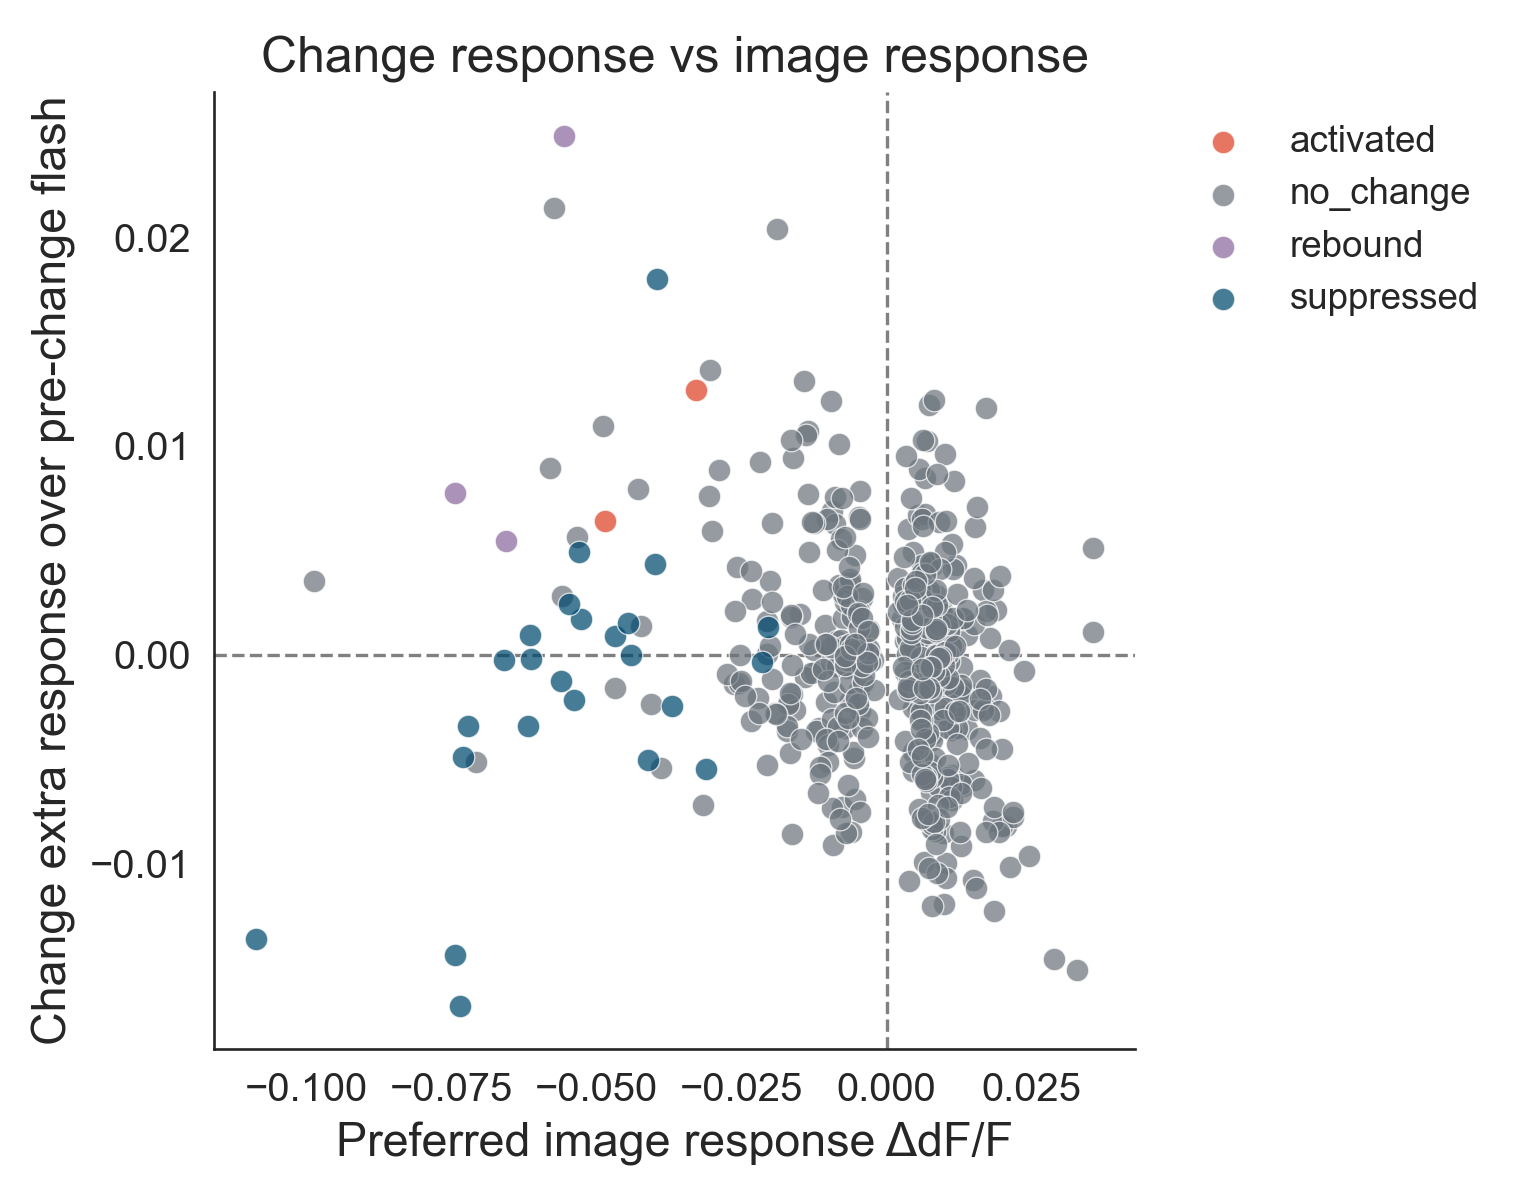

<IPython.core.display.Javascript object>


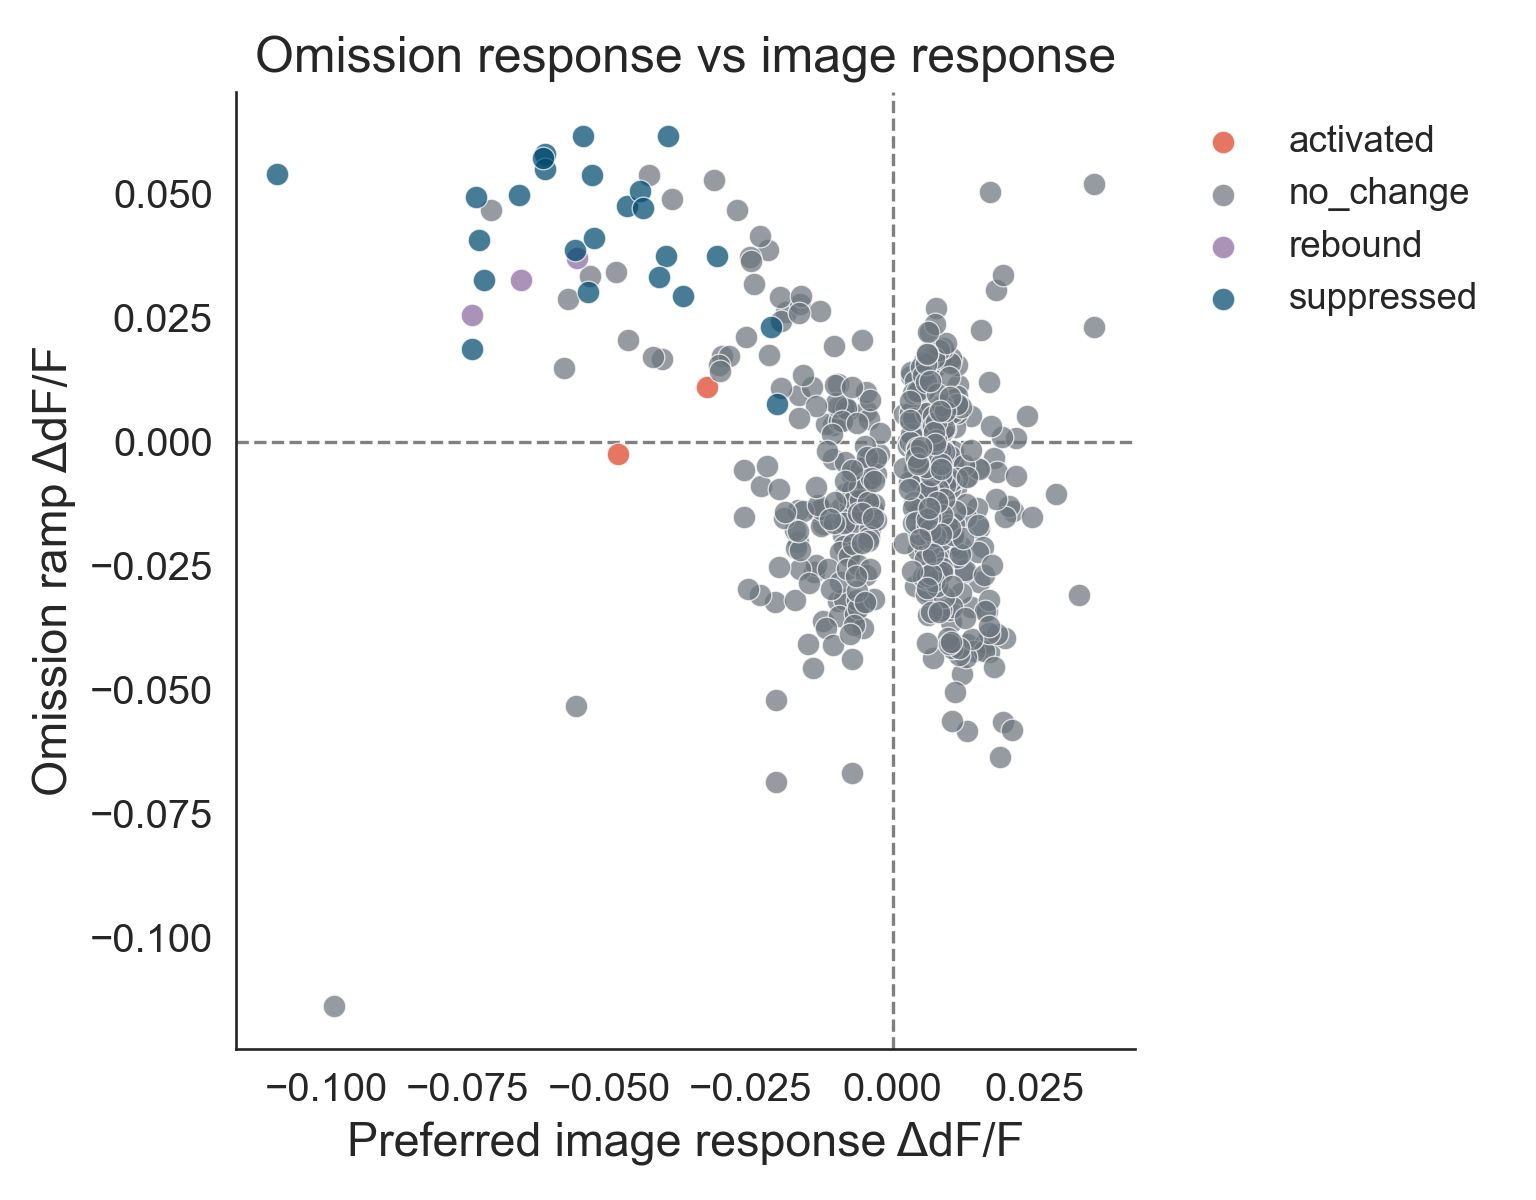

In [17]:

# Change vs image response and omission vs image response.
if len(event_response_df) and len(roi_response_summary):
    merged = event_response_df.merge(
        roi_response_summary[["session_id", "dmd", "roi_idx", "preferred_abs_stim_delta", "response_class", "identity_deviation_fraction"]],
        on=["session_id", "dmd", "roi_idx"],
        how="left",
    )

    for event_type, ycol, ylabel in [
        ("change", "change_extra_delta", "Change extra response over pre-change flash"),
        ("omission", "ramp_delta", "Omission ramp ΔdF/F"),
    ]:
        sub = merged.loc[merged["event_type"].eq(event_type)].copy()
        if sub.empty:
            continue
        fig, ax = plt.subplots(figsize=(6.4, 5.0))
        for cls, cls_sub in sub.groupby("response_class"):
            color = CLASS_COLORS.get(cls, "0.5")
            ax.scatter(
                cls_sub["preferred_abs_stim_delta"],
                cls_sub[ycol],
                s=46,
                alpha=0.72,
                color=color,
                edgecolor="white",
                linewidth=0.4,
                label=str(cls),
            )
        ax.axhline(0, color="0.5", ls="--", lw=1.0, zorder=0)
        ax.axvline(0, color="0.5", ls="--", lw=1.0, zorder=0)
        ax.set_xlabel("Preferred image response ΔdF/F")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{event_type.capitalize()} response vs image response")
        ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
        clean_axes(ax)
        fig.tight_layout()
        maybe_savefig(fig, f"{event_type}_vs_image_response")

# Image sequence analyses

These analyses use the change-locked sequence package. For each changed-to image identity, the repeated sequence starts at position 0 and continues until the next image change. The default response amplitude is the baseline-subtracted mean response during the image-on window.

In [18]:

def sequence_response_from_mean(mean_trace, t, response_window=IMAGE_STIM_WINDOW, baseline_window=IMAGE_BASELINE_WINDOW):
    return response_scalar(mean_trace, t, response_window, baseline_window)


def compute_sequence_tables(sequence_packages):
    position_rows = []
    summary_rows = []
    for session_id, pkg in sequence_packages.items():
        meta = package_session_metadata(session_id)
        t = np.asarray(pkg["timebase_sec"]["image"], dtype=float)
        for dmd_name in [k for k in pkg.keys() if str(k).startswith("DMD")]:
            dmd = int(str(dmd_name).replace("DMD", ""))
            dmd_data = pkg[dmd_name]
            roi_ids = [str(x) for x in dmd_data.get("roi_ids", [])]
            depth = meta.get(f"dmd{dmd}_depth", np.nan)
            stim_dict = dmd_data.get("image_identity", {})
            for roi_idx, roi_id in enumerate(roi_ids):
                all_slopes = []
                all_adapt_idx = []
                all_r0 = []
                all_rlast = []
                for stim_name, seq_data in stim_dict.items():
                    repeated = seq_data.get("repeated", {})
                    if "mean" not in repeated:
                        continue
                    mean_arr = np.asarray(repeated["mean"], dtype=float)[:, roi_idx, :]
                    positions = np.asarray(repeated.get("positions", np.arange(mean_arr.shape[0])), dtype=float)
                    counts = np.asarray(repeated.get("counts", np.ones(mean_arr.shape[0])), dtype=float)
                    tt = t[: mean_arr.shape[1]]
                    amplitudes = np.asarray([sequence_response_from_mean(y, tt) for y in mean_arr], dtype=float)
                    valid = np.isfinite(amplitudes) & np.isfinite(positions) & np.isfinite(counts) & (counts >= SEQUENCE_MIN_COUNT_PER_POSITION)
                    if valid.sum() < SEQUENCE_MIN_POSITIONS:
                        continue
                    pos_v = positions[valid]
                    amp_v = amplitudes[valid]
                    counts_v = counts[valid]
                    order = np.argsort(pos_v)
                    pos_v, amp_v, counts_v = pos_v[order], amp_v[order], counts_v[order]
                    slope, intercept = weighted_slope(pos_v, amp_v, counts_v)
                    r0 = float(amp_v[0])
                    rlast = float(amp_v[-1])
                    adaptation_index = float((r0 - rlast) / (abs(r0) + abs(rlast) + EPS))
                    sequence_class = classify_sequence_slope(slope)
                    all_slopes.append(slope)
                    all_adapt_idx.append(adaptation_index)
                    all_r0.append(r0)
                    all_rlast.append(rlast)

                    for p, amp, count in zip(pos_v, amp_v, counts_v):
                        position_rows.append({
                            "session_id": session_id,
                            "subject_id": meta.get("subject_id", pkg.get("metadata", {}).get("subject_id", np.nan)),
                            "session_number": meta.get("session_#", meta.get("session_number", np.nan)),
                            "session_type": meta.get("session_type", "unknown"),
                            "stimulus_set": meta.get("stimulus", "unknown"),
                            "dmd": dmd,
                            "depth_um": depth,
                            "roi_idx": roi_idx,
                            "roi_id": roi_id,
                            "stimulus_name": str(stim_name),
                            "stimulus_label": stim_label(stim_name),
                            "sequence_position": int(p),
                            "counts": float(count),
                            "response_amplitude": float(amp),
                            "response_minus_r0": float(amp - r0),
                            "sequence_slope": slope,
                            "sequence_intercept": intercept,
                            "adaptation_index": adaptation_index,
                            "sequence_class": sequence_class,
                        })
                if len(all_slopes):
                    median_slope = float(np.nanmedian(all_slopes))
                    summary_rows.append({
                        "session_id": session_id,
                        "subject_id": meta.get("subject_id", pkg.get("metadata", {}).get("subject_id", np.nan)),
                        "session_number": meta.get("session_#", meta.get("session_number", np.nan)),
                        "session_type": meta.get("session_type", "unknown"),
                        "stimulus_set": meta.get("stimulus", "unknown"),
                        "dmd": dmd,
                        "depth_um": depth,
                        "roi_idx": roi_idx,
                        "roi_id": roi_id,
                        "n_images_with_sequences": int(len(all_slopes)),
                        "median_sequence_slope": median_slope,
                        "mean_sequence_slope": float(np.nanmean(all_slopes)),
                        "median_adaptation_index": float(np.nanmedian(all_adapt_idx)),
                        "median_r0": float(np.nanmedian(all_r0)),
                        "median_rlast": float(np.nanmedian(all_rlast)),
                        "sequence_class": classify_sequence_slope(median_slope),
                    })
    return pd.DataFrame(position_rows), pd.DataFrame(summary_rows)

sequence_position_df, sequence_summary_df = compute_sequence_tables(sequence_packages)
print("sequence_position_df", sequence_position_df.shape)
print("sequence_summary_df", sequence_summary_df.shape)
display(sequence_summary_df.head())

if SAVE_TABLES and len(sequence_summary_df):
    try:
        table_dir = SAVE_PATH / "tables"
        table_dir.mkdir(parents=True, exist_ok=True)
        sequence_position_df.to_csv(table_dir / f"{today_str}_asap7_sequence_position_table.csv", index=False)
        sequence_summary_df.to_csv(table_dir / f"{today_str}_asap7_sequence_roi_summary.csv", index=False)
    except Exception as exc:
        print(f"Could not save sequence tables: {exc}")

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_34996\2147653345.py:14: RuntimeWarning: Mean of empty slice
  return float(np.nanmean(np.asarray(trace)[mask]))


sequence_position_df (40456, 19)
sequence_summary_df (490, 16)


,session_id,subject_id,session_number,session_type,stimulus_set,dmd,depth_um,roi_idx,roi_id,n_images_with_sequences,median_sequence_slope,mean_sequence_slope,median_adaptation_index,median_r0,median_rlast,sequence_class
0,826031_2026-01-30_15-04-02,826031,2,familiar,images_A,1,50,0,DMD1_roi0000,7,-0.000255,-0.000250,0.890561,0.000927,-0.016376,stable
1,826031_2026-01-30_15-04-02,826031,2,familiar,images_A,1,50,1,DMD1_roi0001,7,-0.000447,-0.000101,0.703910,0.002118,-0.020922,stable
2,826031_2026-01-30_15-04-02,826031,2,familiar,images_A,1,50,2,DMD1_roi0002,7,-0.000303,-0.000574,1.000000,0.003461,-0.007755,stable
3,826031_2026-01-30_15-04-02,826031,2,familiar,images_A,1,50,3,DMD1_roi0003,7,-0.000690,-0.000267,0.909821,0.006171,-0.010950,adapting
4,826031_2026-01-30_15-04-02,826031,2,familiar,images_A,1,50,4,DMD1_roi0004,7,-0.001336,-0.000712,1.000000,0.003950,-0.030751,adapting


## Example sequence profile

The plot below shows repeated image responses for one ROI/image. It is intentionally simple; change the selected ROI or image to inspect other cases.

<IPython.core.display.Javascript object>


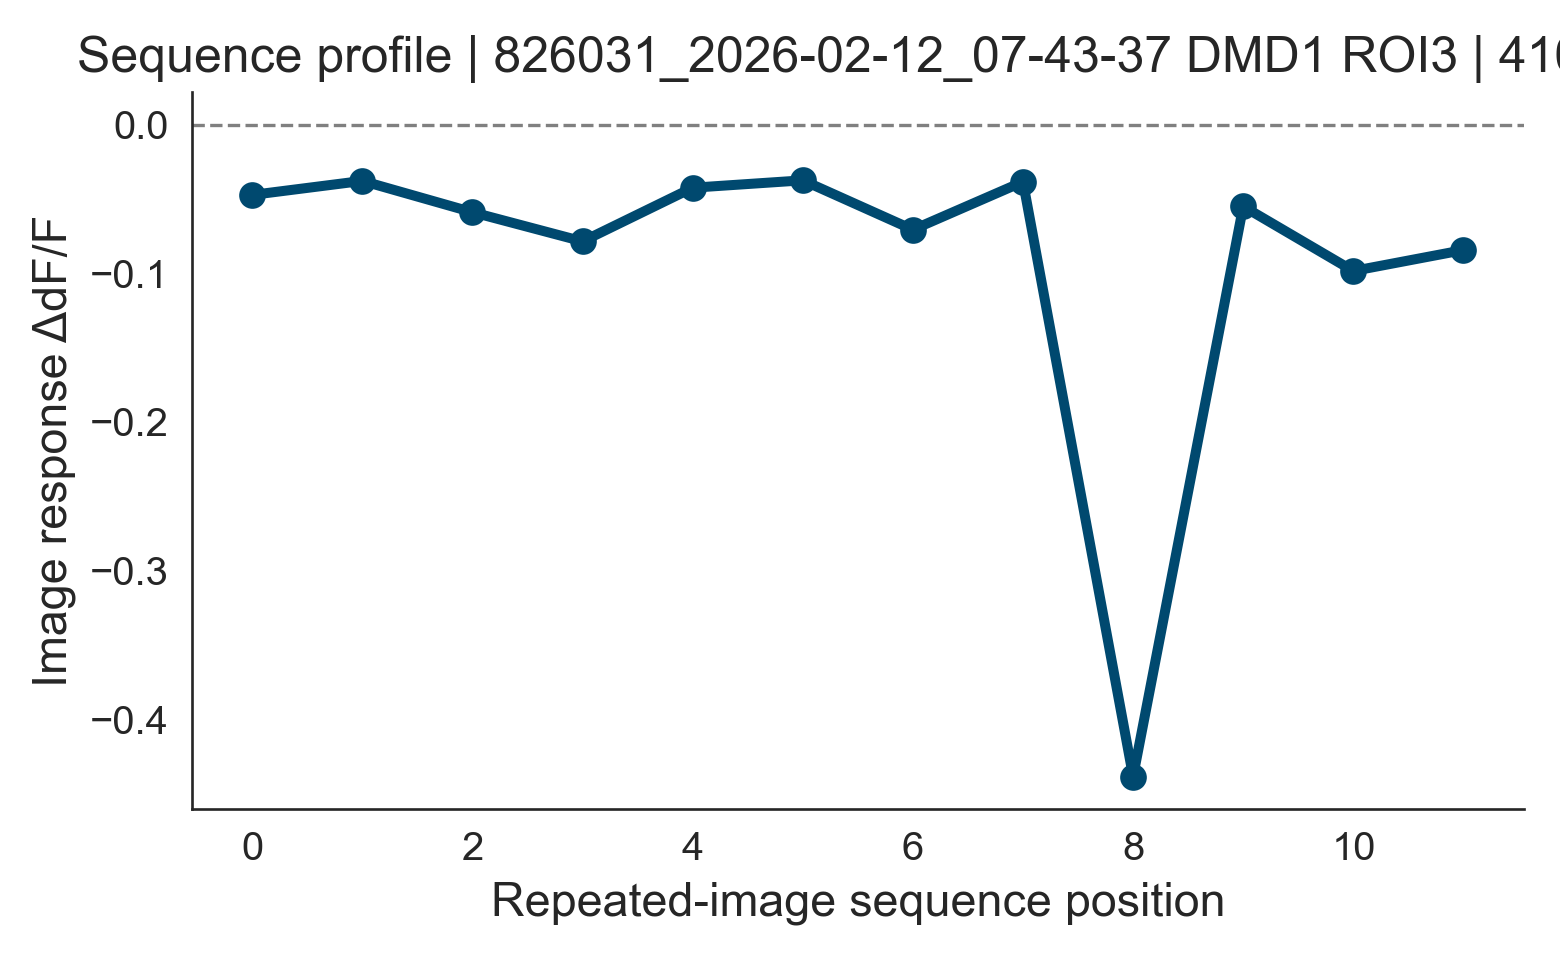

In [19]:

if len(sequence_position_df):
    # Choose an informative ROI/image: largest absolute slope.
    ex_seq = sequence_position_df.reindex(sequence_position_df["sequence_slope"].abs().sort_values(ascending=False).index).iloc[0]
    ssid = ex_seq["session_id"]
    sdmd = int(ex_seq["dmd"])
    sroi = int(ex_seq["roi_idx"])
    stim = ex_seq["stimulus_label"]
    sub = sequence_position_df.loc[
        sequence_position_df["session_id"].eq(ssid)
        & sequence_position_df["dmd"].eq(sdmd)
        & sequence_position_df["roi_idx"].eq(sroi)
        & sequence_position_df["stimulus_label"].eq(stim)
    ].sort_values("sequence_position")

    fig, ax = plt.subplots(figsize=(6.5, 4.0))
    ax.plot(sub["sequence_position"], sub["response_amplitude"], marker="o", color="#00496f", lw=3.0, ms=7)
    ax.axhline(0, color="0.5", lw=1.0, ls="--", zorder=0)
    ax.set_xlabel("Repeated-image sequence position")
    ax.set_ylabel("Image response ΔdF/F")
    ax.set_title(f"Sequence profile | {ssid} DMD{sdmd} ROI{sroi} | {stim}")
    clean_axes(ax)
    fig.tight_layout()
    maybe_savefig(fig, f"example_sequence_{ssid}_DMD{sdmd}_ROI{sroi}_{stim}")
else:
    print("No sequence_position_df available.")

<IPython.core.display.Javascript object>


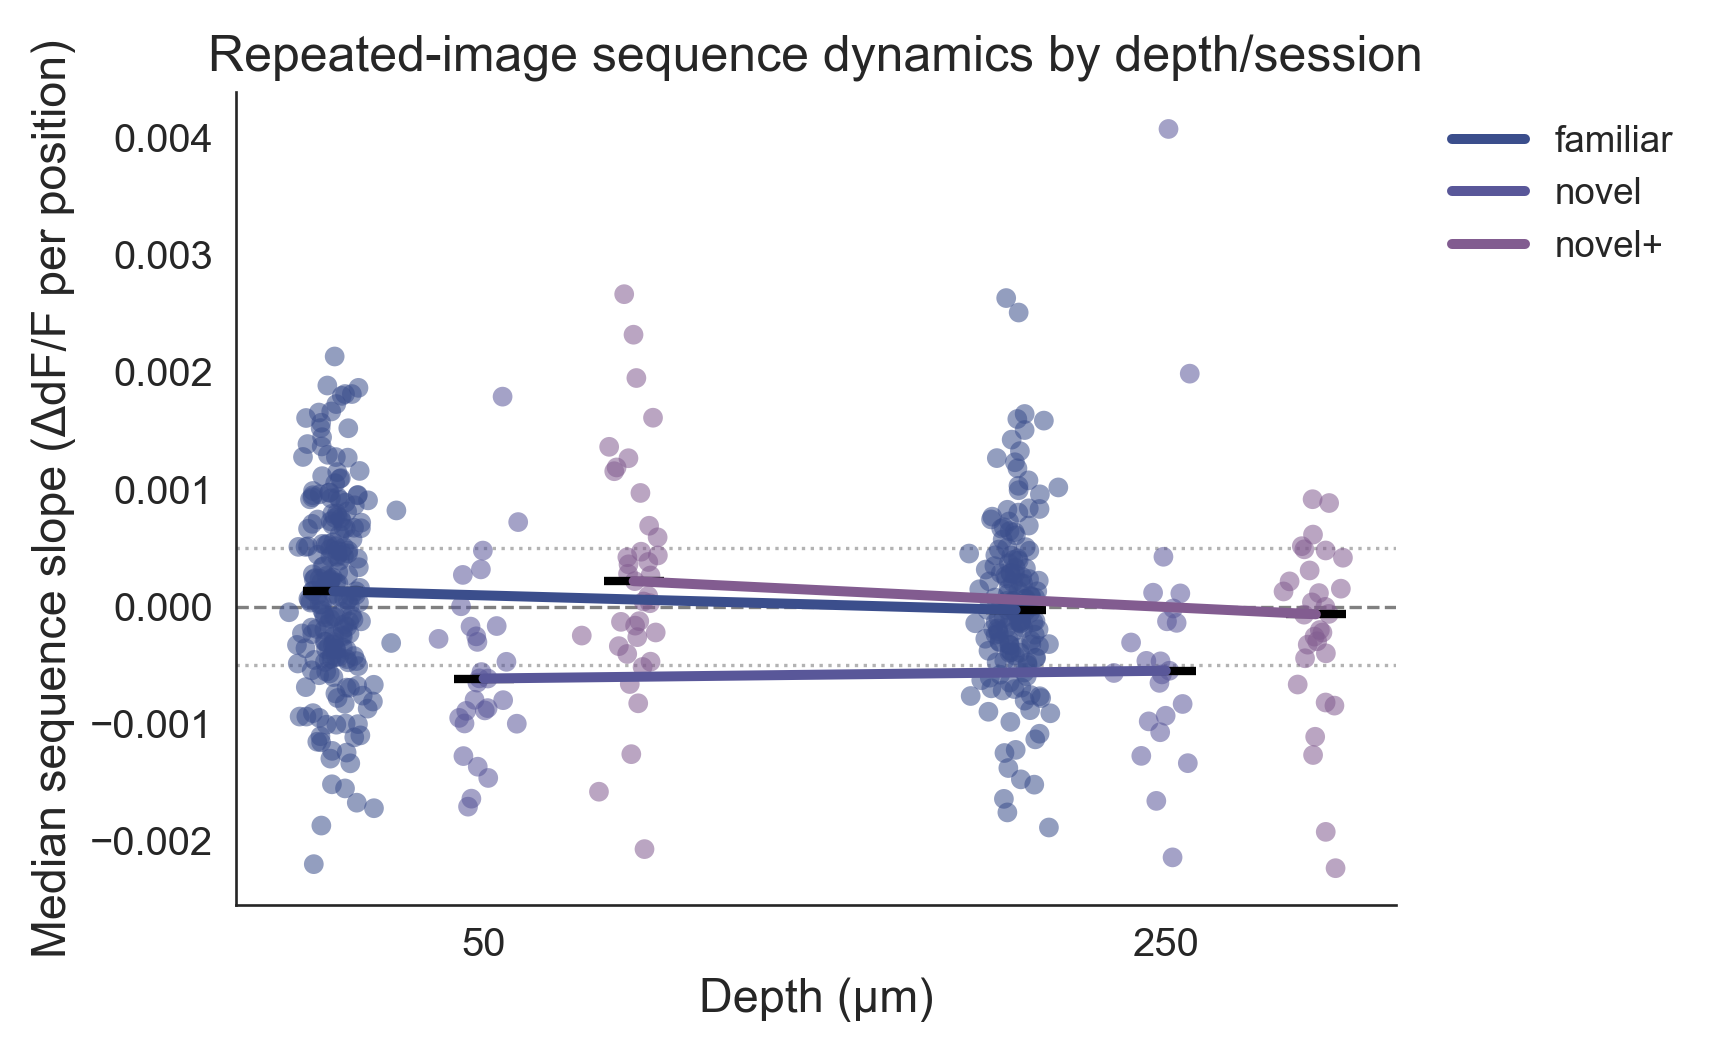

In [20]:

# Sequence slope summary by depth/session.
if len(sequence_summary_df):
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    x_categories = sorted(sequence_summary_df["depth_um"].dropna().unique())
    session_types = list(pd.unique(sequence_summary_df["session_type"]))
    offsets = np.linspace(-0.22, 0.22, max(len(session_types), 1))

    for j, session_type in enumerate(session_types):
        sub = sequence_summary_df.loc[sequence_summary_df["session_type"].eq(session_type)].copy()
        color = SESSION_COLORS[j % len(SESSION_COLORS)]
        medians = []
        for i, depth in enumerate(x_categories):
            vals = sub.loc[sub["depth_um"].eq(depth), "median_sequence_slope"].to_numpy(dtype=float)
            vals = vals[np.isfinite(vals)]
            medians.append(np.nanmedian(vals) if vals.size else np.nan)
            if vals.size:
                rng = np.random.default_rng(2244 + i + j)
                jitter = rng.normal(0, 0.025, size=vals.size)
                ax.scatter(np.full(vals.size, i + offsets[j]) + jitter, vals, color=color, alpha=0.55, s=35, edgecolor="none")
                ax.plot(i + offsets[j], np.nanmedian(vals), marker="_", markersize=18, color="black", mew=2.5)
        ax.plot(np.arange(len(x_categories)) + offsets[j], medians, color=color, lw=3.0, label=str(session_type))

    ax.axhline(0, color="0.5", lw=1.0, ls="--", zorder=0)
    ax.axhline(SEQUENCE_SLOPE_THRESHOLD, color="0.7", lw=1.0, ls=":", zorder=0)
    ax.axhline(-SEQUENCE_SLOPE_THRESHOLD, color="0.7", lw=1.0, ls=":", zorder=0)
    ax.set_xticks(np.arange(len(x_categories)))
    ax.set_xticklabels([f"{d:g}" for d in x_categories])
    ax.set_xlabel("Depth (µm)")
    ax.set_ylabel("Median sequence slope (ΔdF/F per position)")
    ax.set_title("Repeated-image sequence dynamics by depth/session")
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    clean_axes(ax)
    fig.tight_layout()
    maybe_savefig(fig, "sequence_slope_by_depth_session")

<IPython.core.display.Javascript object>


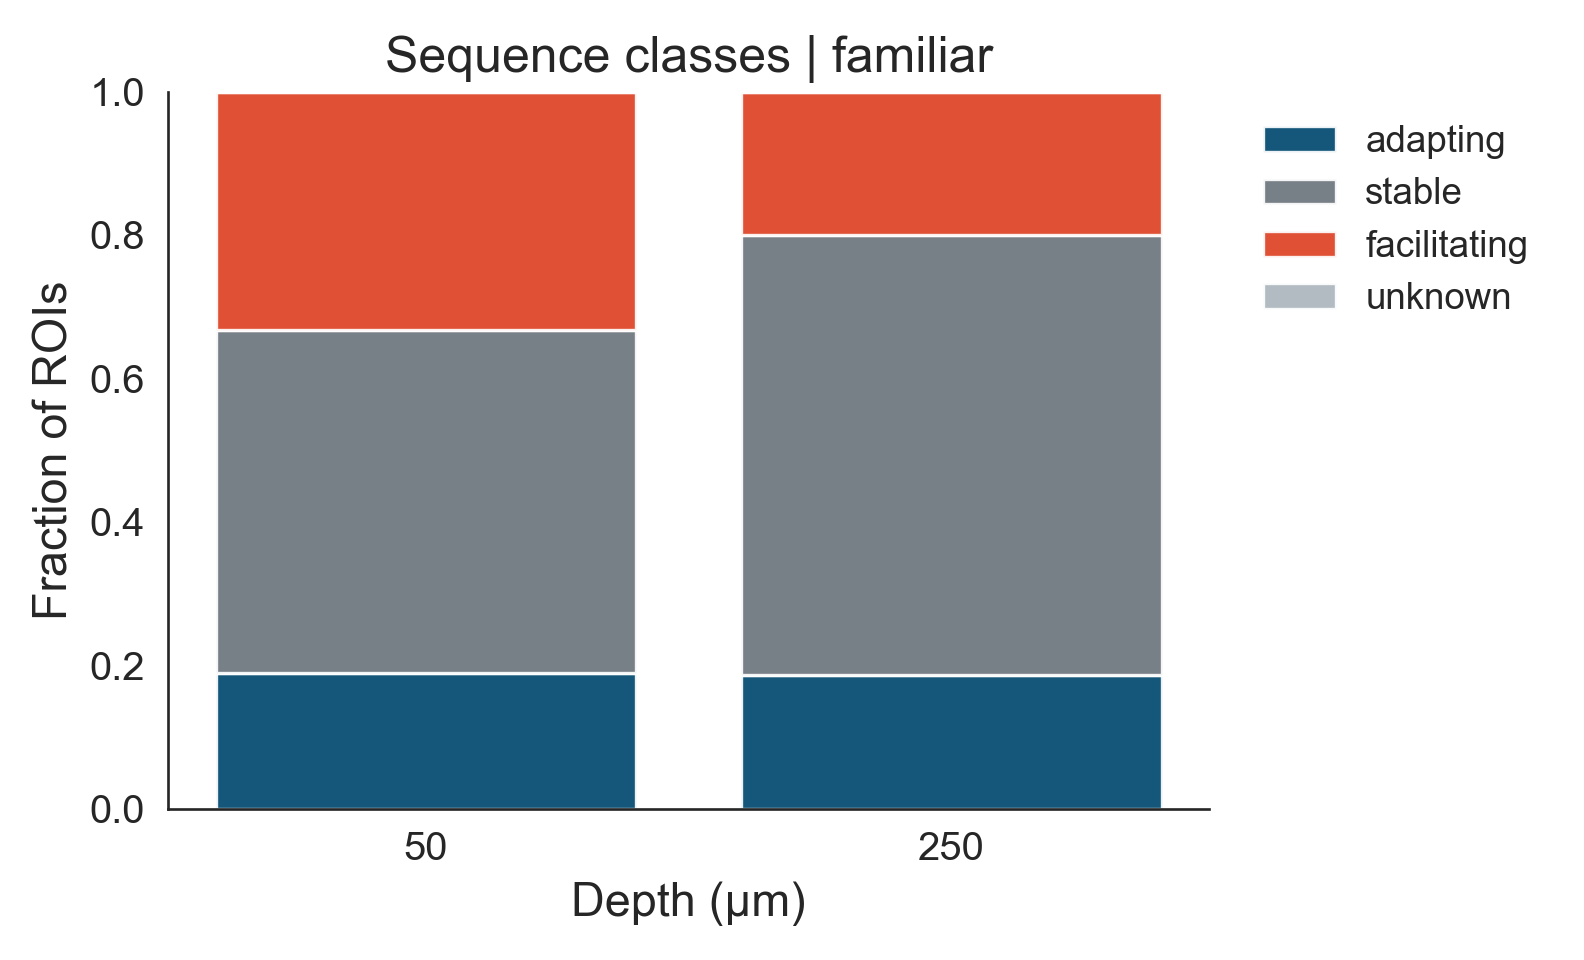

<IPython.core.display.Javascript object>


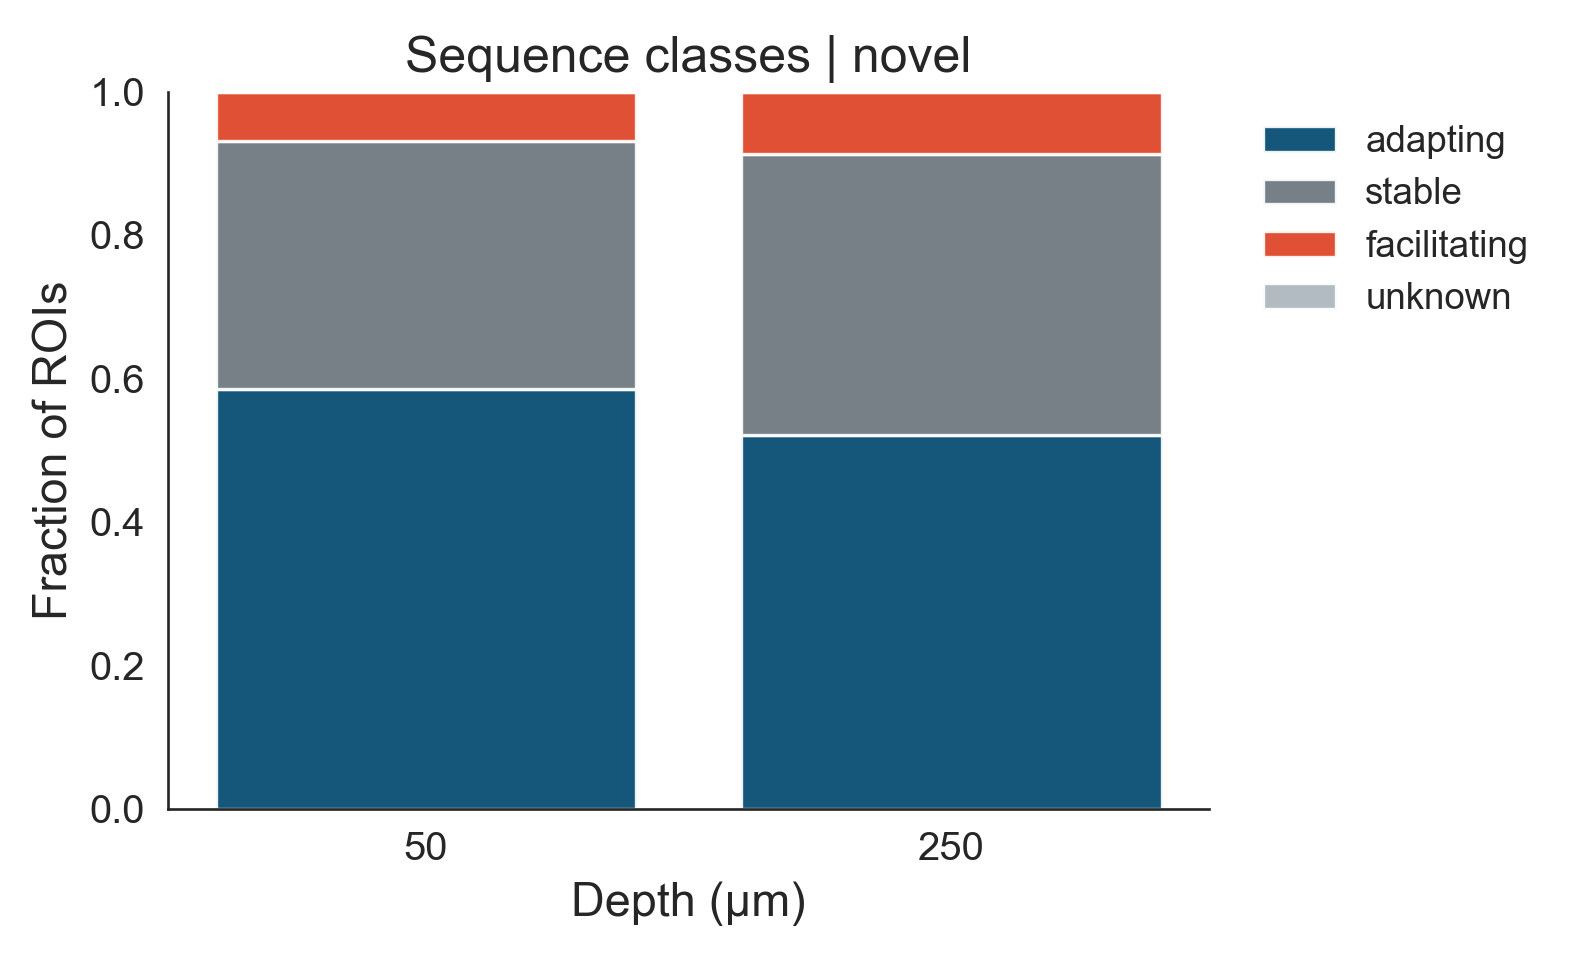

<IPython.core.display.Javascript object>


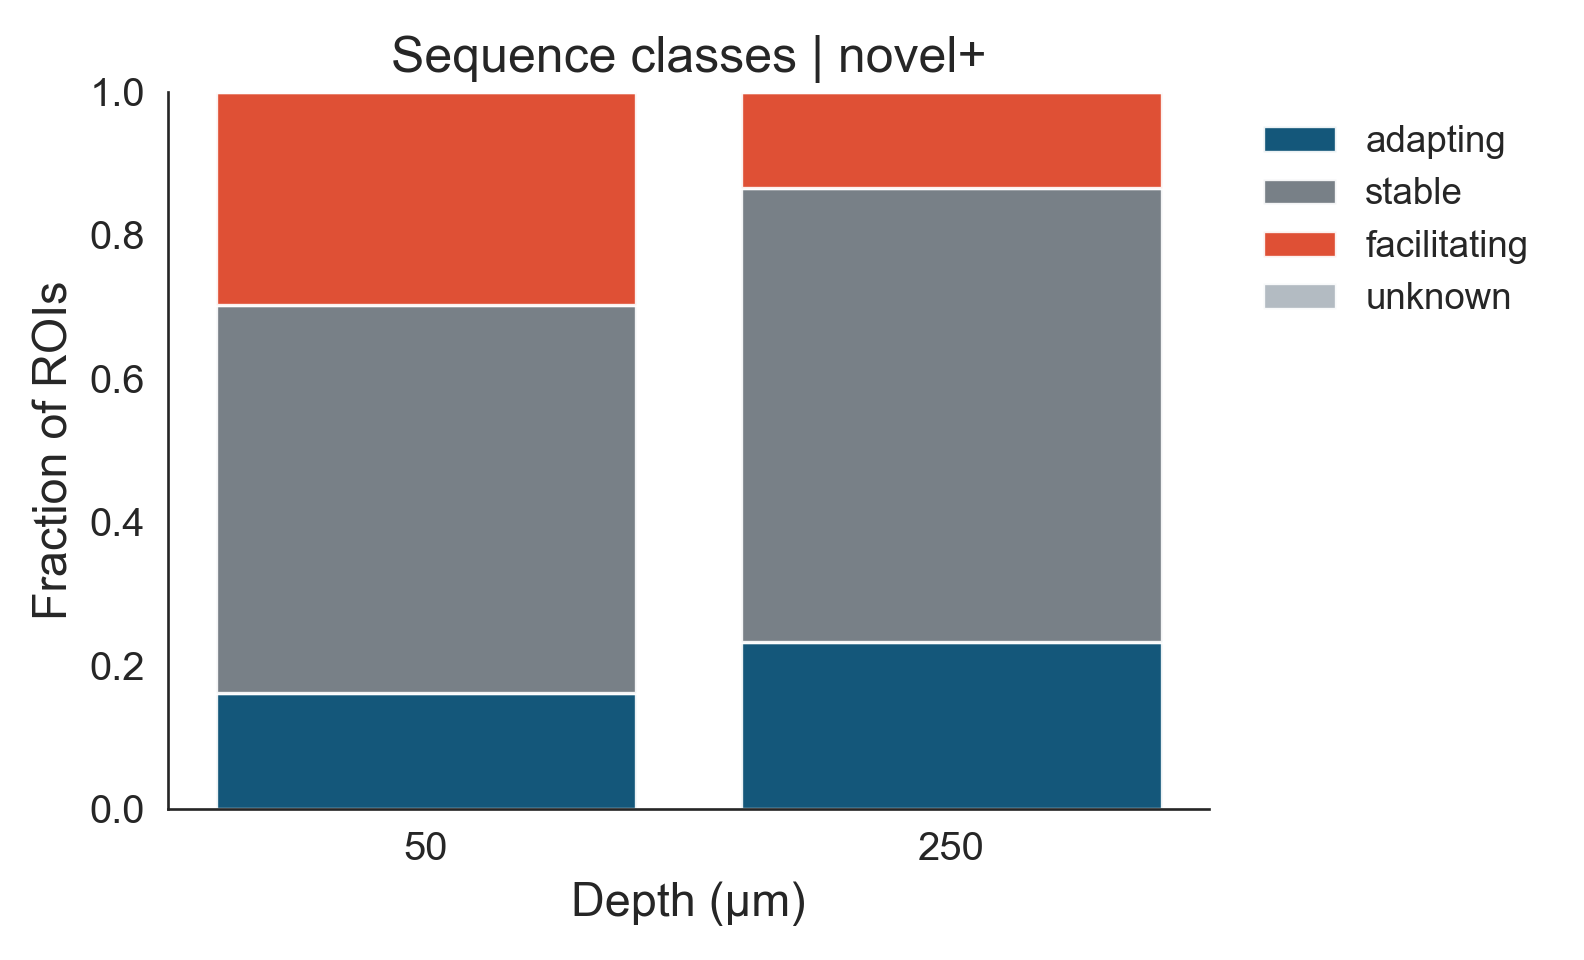

In [21]:

# Fraction adapting/facilitating/stable by depth/session type.
if len(sequence_summary_df):
    seq_counts = (
        sequence_summary_df
        .groupby(["session_type", "depth_um", "sequence_class"], dropna=False)
        .size()
        .rename("n")
        .reset_index()
    )
    seq_counts["fraction"] = seq_counts["n"] / seq_counts.groupby(["session_type", "depth_um"], dropna=False)["n"].transform("sum")
    seq_class_colors = {"facilitating": "#dd4124", "adapting": "#00496f", "stable": "#6c757d", "unknown": "#adb5bd"}

    for session_type in pd.unique(seq_counts["session_type"]):
        sub = seq_counts.loc[seq_counts["session_type"].eq(session_type)]
        depths = sorted(sub["depth_um"].dropna().unique())
        x = np.arange(len(depths))
        bottom = np.zeros(len(depths))
        fig, ax = plt.subplots(figsize=(6.6, 4.0))
        for cls in ["adapting", "stable", "facilitating", "unknown"]:
            y = []
            for depth in depths:
                vals = sub.loc[sub["depth_um"].eq(depth) & sub["sequence_class"].eq(cls), "fraction"]
                y.append(float(vals.iloc[0]) if len(vals) else 0.0)
            ax.bar(x, y, bottom=bottom, color=seq_class_colors[cls], alpha=0.92, label=cls)
            bottom += np.asarray(y)
        ax.set_xticks(x)
        ax.set_xticklabels([f"{d:g}" for d in depths])
        ax.set_ylim(0, 1)
        ax.set_xlabel("Depth (µm)")
        ax.set_ylabel("Fraction of ROIs")
        ax.set_title(f"Sequence classes | {session_type}")
        ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
        clean_axes(ax)
        fig.tight_layout()
        maybe_savefig(fig, f"sequence_class_fraction_{session_type}")

# Optional: single-trial image identity FVE from full session H5

The mean NPZ supports fast image-mean analyses, but true trial-level FVE requires extracting individual flash responses from the full session H5 and the corrected stimulus table. This cell is intentionally opt-in because reading many ROIs from the full 10.5 kHz traces can be slow.

Recommended first pass: run this on a small ROI subset, then scale to all sessions overnight if useful.

In [22]:

def _find_existing_corrected_bonsai(asset_row):
    # Prefer registry asset path if present in session_table; otherwise search under session_dir.
    candidates = []
    if "bonsai_event_log_csv" in asset_row and pd.notna(asset_row.get("bonsai_event_log_csv")):
        candidates.append(Path(str(asset_row["bonsai_event_log_csv"])))
    session_dir = Path(str(asset_row.get("session_dir", "")))
    if session_dir.exists():
        candidates.extend(sorted(session_dir.glob("**/bonsai_event_log_corrected.csv")))
        candidates.extend(sorted(session_dir.glob("**/bonsai_event_log.csv")))
    for p in candidates:
        if p.exists():
            return p
    return None


def load_ordered_images_for_session(row, windows_prepost=(0.25, 0.50)):
    if load_corrected_bonsai_csv is None:
        raise ImportError("common.alignment helpers are not available.")
    bonsai_csv = _find_existing_corrected_bonsai(row)
    if bonsai_csv is None:
        raise FileNotFoundError("No bonsai_event_log csv found for this row.")
    stim_df = load_corrected_bonsai_csv(bonsai_csv)
    image_times, ordered_images = extract_image_intervals(stim_df)
    extract_ordered_change_targets(stim_df, ordered_images)

    epochs_csv = Path(str(row.get("imaging_epochs_csv", "")))
    if epochs_csv.exists():
        epoch_df = load_imaging_epochs_csv(epochs_csv)
        ordered_images = filter_ordered_images_to_epochs(
            ordered_images,
            epoch_df,
            pre_time=windows_prepost[0],
            post_time=windows_prepost[1],
        )
    return ordered_images


def compute_single_roi_trial_fve_from_h5(row, dmd=1, roi_idx=0, signal=SIGNAL, response_window=IMAGE_STIM_WINDOW, baseline_window=IMAGE_BASELINE_WINDOW):
    """Compute scalar image-identity FVE for one ROI from the full session trace H5."""
    h5_path = Path(str(row["session_trace_h5"]))
    if not h5_path.exists():
        raise FileNotFoundError(h5_path)
    ordered_images = load_ordered_images_for_session(row, windows_prepost=(abs(baseline_window[0]), response_window[1]))
    if len(ordered_images) == 0:
        raise ValueError("No image events after epoch filtering.")

    values = []
    labels = []
    with h5py.File(h5_path, "r") as f:
        g = f[f"DMD{dmd}"]
        t = np.asarray(g["timebase_sec"])
        ds = g[signal]
        # Read one ROI trace into memory (~75 MB for 19M samples); okay for small ROI subsets.
        trace = np.asarray(ds[roi_idx], dtype=float)
        for evt in ordered_images:
            onset = float(evt.onset)
            b0, b1 = onset + baseline_window[0], onset + baseline_window[1]
            r0, r1 = onset + response_window[0], onset + response_window[1]
            ib0, ib1 = np.searchsorted(t, [b0, b1])
            ir0, ir1 = np.searchsorted(t, [r0, r1])
            if ib0 < 0 or ir0 < 0 or ib1 > len(t) or ir1 > len(t) or ib1 <= ib0 or ir1 <= ir0:
                continue
            val = float(np.nanmean(trace[ir0:ir1]) - np.nanmean(trace[ib0:ib1]))
            values.append(val)
            labels.append(evt.image_name)

    values = np.asarray(values, dtype=float)
    labels = np.asarray(labels)
    finite = np.isfinite(values)
    values = values[finite]
    labels = labels[finite]
    if values.size < 2:
        return {"image_fve": np.nan, "n_trials": int(values.size), "n_images": int(len(set(labels)))}
    total_var = float(np.var(values))
    if total_var <= EPS:
        return {"image_fve": 0.0, "total_var": total_var, "residual_var": total_var, "n_trials": int(values.size), "n_images": int(len(set(labels)))}
    pred = np.empty_like(values)
    for lab in np.unique(labels):
        pred[labels == lab] = np.mean(values[labels == lab])
    resid = values - pred
    residual_var = float(np.var(resid))
    return {
        "session_id": row["session_id"],
        "dmd": int(dmd),
        "roi_idx": int(roi_idx),
        "image_fve": float(1.0 - residual_var / total_var),
        "total_var": total_var,
        "residual_var": residual_var,
        "n_trials": int(values.size),
        "n_images": int(len(np.unique(labels))),
    }

# Example use: uncomment when running on the network with visible H5 files.
# row = session_table.loc[session_table["session_trace_h5_exists"]].iloc[0]
# fve_one = compute_single_roi_trial_fve_from_h5(row, dmd=1, roi_idx=0)
# fve_one

# Optional: ROI map overlay from voltage summary MAT

This cell is useful for sanity-checking whether DMD depth/ROI identity are being interpreted correctly. It uses `VoltageSummary` when available.

<IPython.core.display.Javascript object>


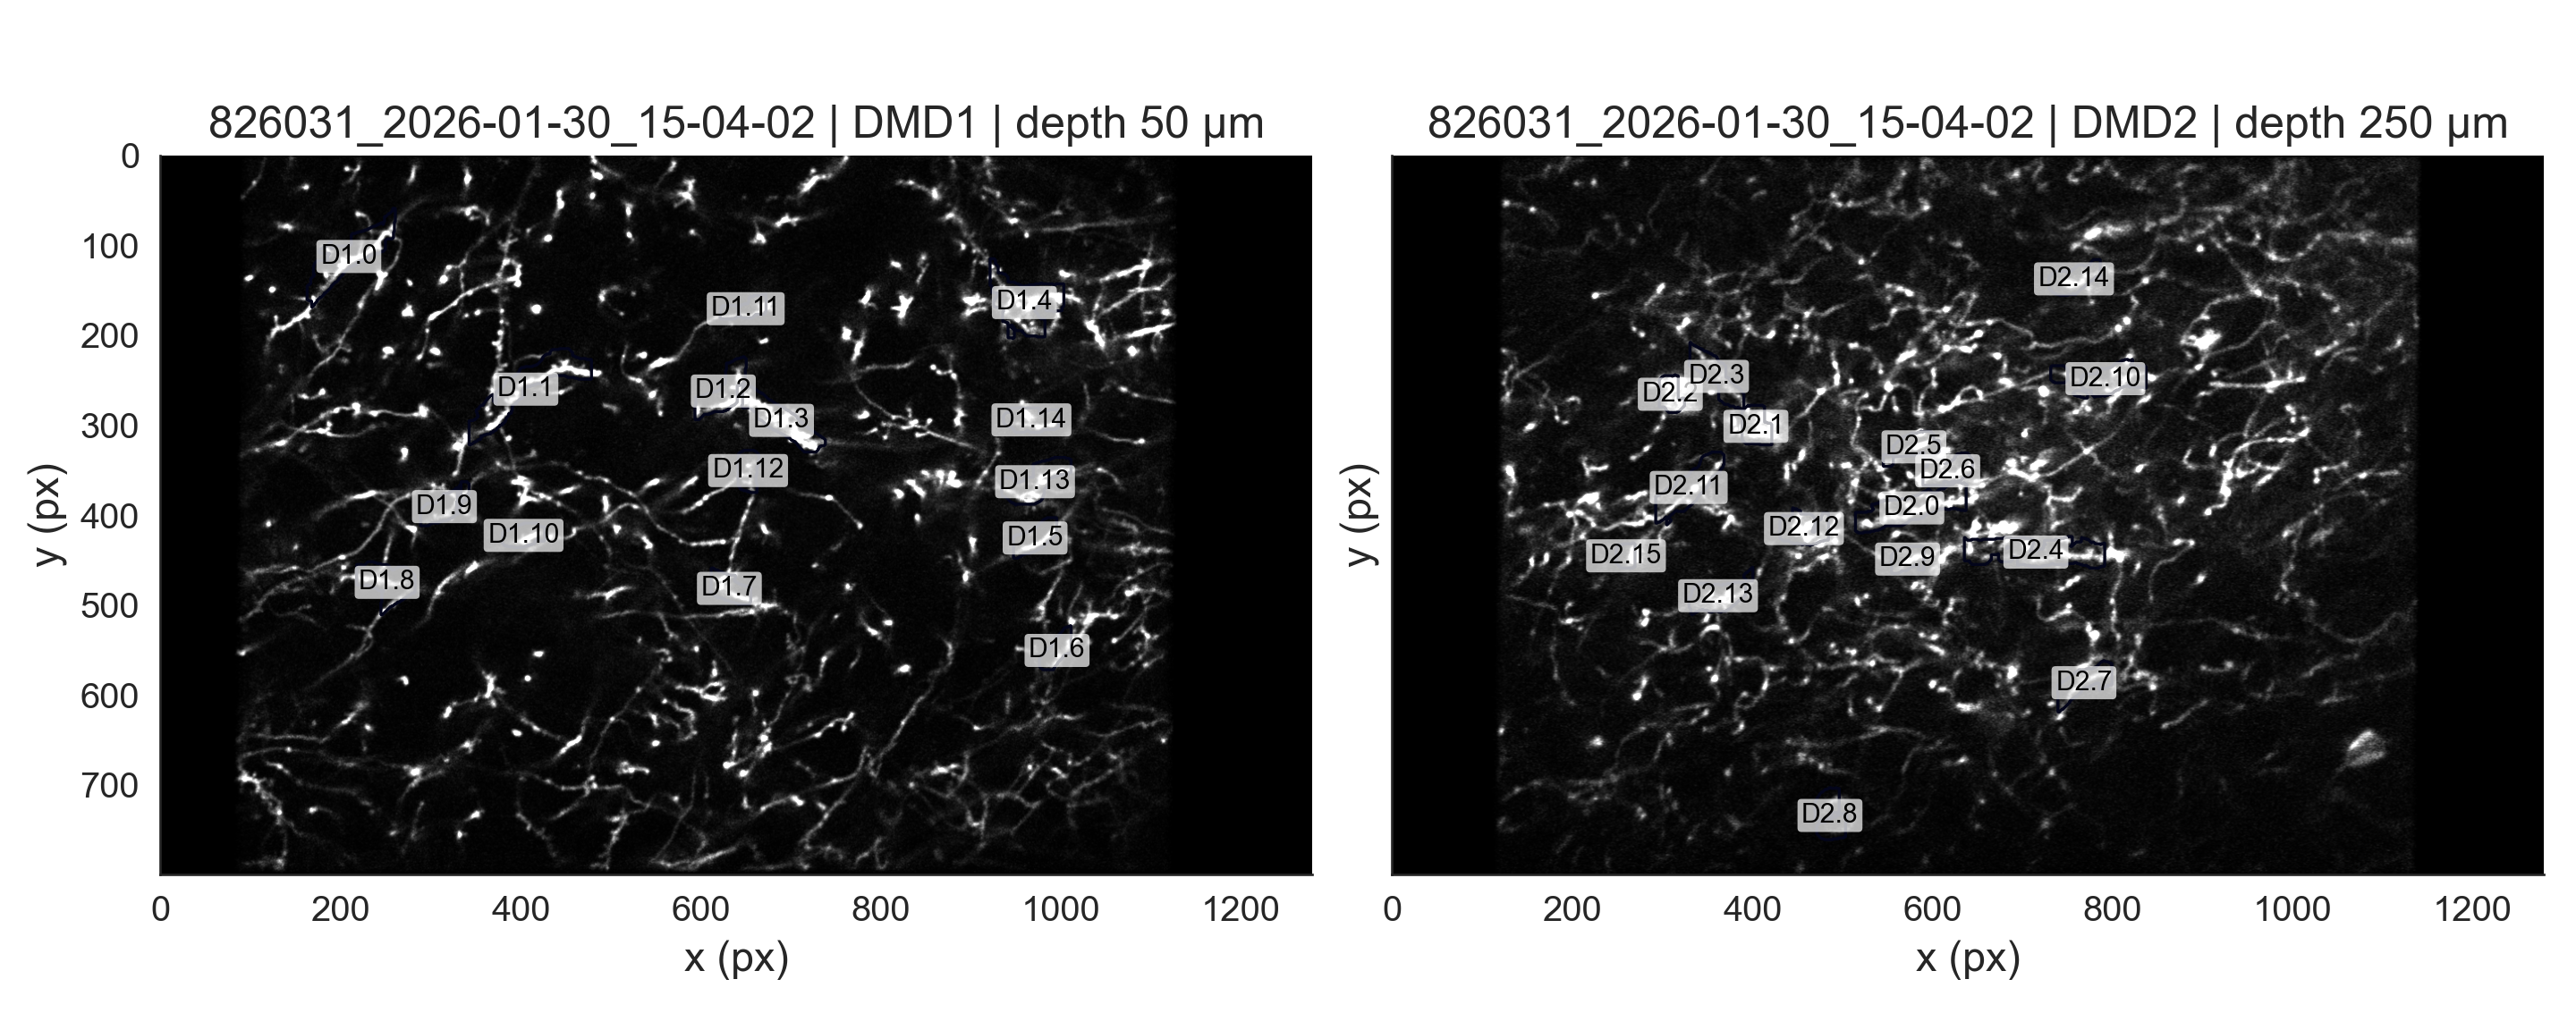

In [23]:

def overlay_roi_masks(ax, masks, label_prefix="", contour_lw=1.0):
    """Overlay ROI contours and labels on an image axis."""
    if masks.ndim == 3 and masks.shape[-1] < masks.shape[0]:
        n_rois = masks.shape[-1]
    elif masks.ndim == 3:
        n_rois = masks.shape[-1]
    else:
        return ax
    for roi_idx in range(n_rois):
        mask = masks[..., roi_idx]
        if not np.any(mask):
            continue
        ax.contour(mask.astype(float), levels=[0.5], linewidths=contour_lw)
        yy, xx = np.nonzero(mask)
        ax.text(
            float(np.mean(xx)),
            float(np.mean(yy)),
            f"{label_prefix}{roi_idx}",
            ha="center",
            va="center",
            fontsize=9,
            color="black",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.70),
        )
    return ax

# Example use. This needs a visible voltage summary MAT.
summary_rows = session_table.loc[session_table.get("voltage_summary_mat_exists", False).astype(bool)] if "voltage_summary_mat_exists" in session_table else pd.DataFrame()
if VoltageSummary is not None and len(summary_rows):
    row = summary_rows.iloc[0]
    summary_mat = Path(str(row["voltage_summary_mat"]))
    try:
        vs = VoltageSummary(summary_mat, keep_open=True)
        fig, axes = plt.subplots(1, int(vs.n_dmds), figsize=(6.0 * int(vs.n_dmds), 4.8), sharex=True, sharey=True)
        axes = np.atleast_1d(axes)
        for dmd, ax in enumerate(axes, start=1):
            im = vs.get_mean_image(dmd=dmd)
            masks = vs.get_roi_masks(dmd=dmd)
            vmax = np.nanpercentile(im, 99)
            ax.imshow(im, cmap="gray", vmax=vmax)
            overlay_roi_masks(ax, masks, label_prefix=f"D{dmd}.")
            ax.set_title(f"{row['session_id']} | DMD{dmd} | depth {row.get(f'dmd{dmd}_depth', np.nan)} µm")
            ax.set_xlabel("x (px)")
            ax.set_ylabel("y (px)")
            clean_axes(ax)
        fig.tight_layout()
        maybe_savefig(fig, f"roi_overlay_{row['session_id']}")
        vs.close()
    except Exception as exc:
        print(f"ROI overlay failed: {exc}")
else:
    print("No visible voltage summary MAT or VoltageSummary import unavailable.")

# Composite depth/session dashboard

This compact set of panels is a good candidate for lab-meeting summary figures. It keeps analysis close to the data while surfacing the main effects:

- fraction of activated/suppressed/biphasic ROIs,
- image identity deviation fraction,
- sequence adaptation/facilitation,
- omission ramp strength.

,session_id,session_number,session_type,depth_um,n_rois,frac_activated,frac_suppressed,median_identity_fraction,median_image_response,median_sequence_slope,median_omission_ramp,median_change_extra
0,826031_2026-01-30_15-04-02,2,familiar,50,12,0.0,0.0,0.791025,0.018392,-0.000431,-0.008731,-0.007626
20,826032_2026-01-29_12-59-37,2,familiar,50,8,0.0,0.0,0.880547,0.005368,-0.000239,-0.001356,0.000982
1,826031_2026-01-30_15-04-02,2,familiar,250,13,0.0,0.0,0.861630,0.015178,-0.000387,-0.005194,-0.005974
21,826032_2026-01-29_12-59-37,2,familiar,250,9,0.0,0.0,0.891776,0.004476,-0.000334,-0.001698,0.001906
2,826031_2026-02-01_11-01-50,3,familiar,50,15,0.0,0.0,0.914716,0.008026,0.000241,-0.007625,-0.006571


<IPython.core.display.Javascript object>


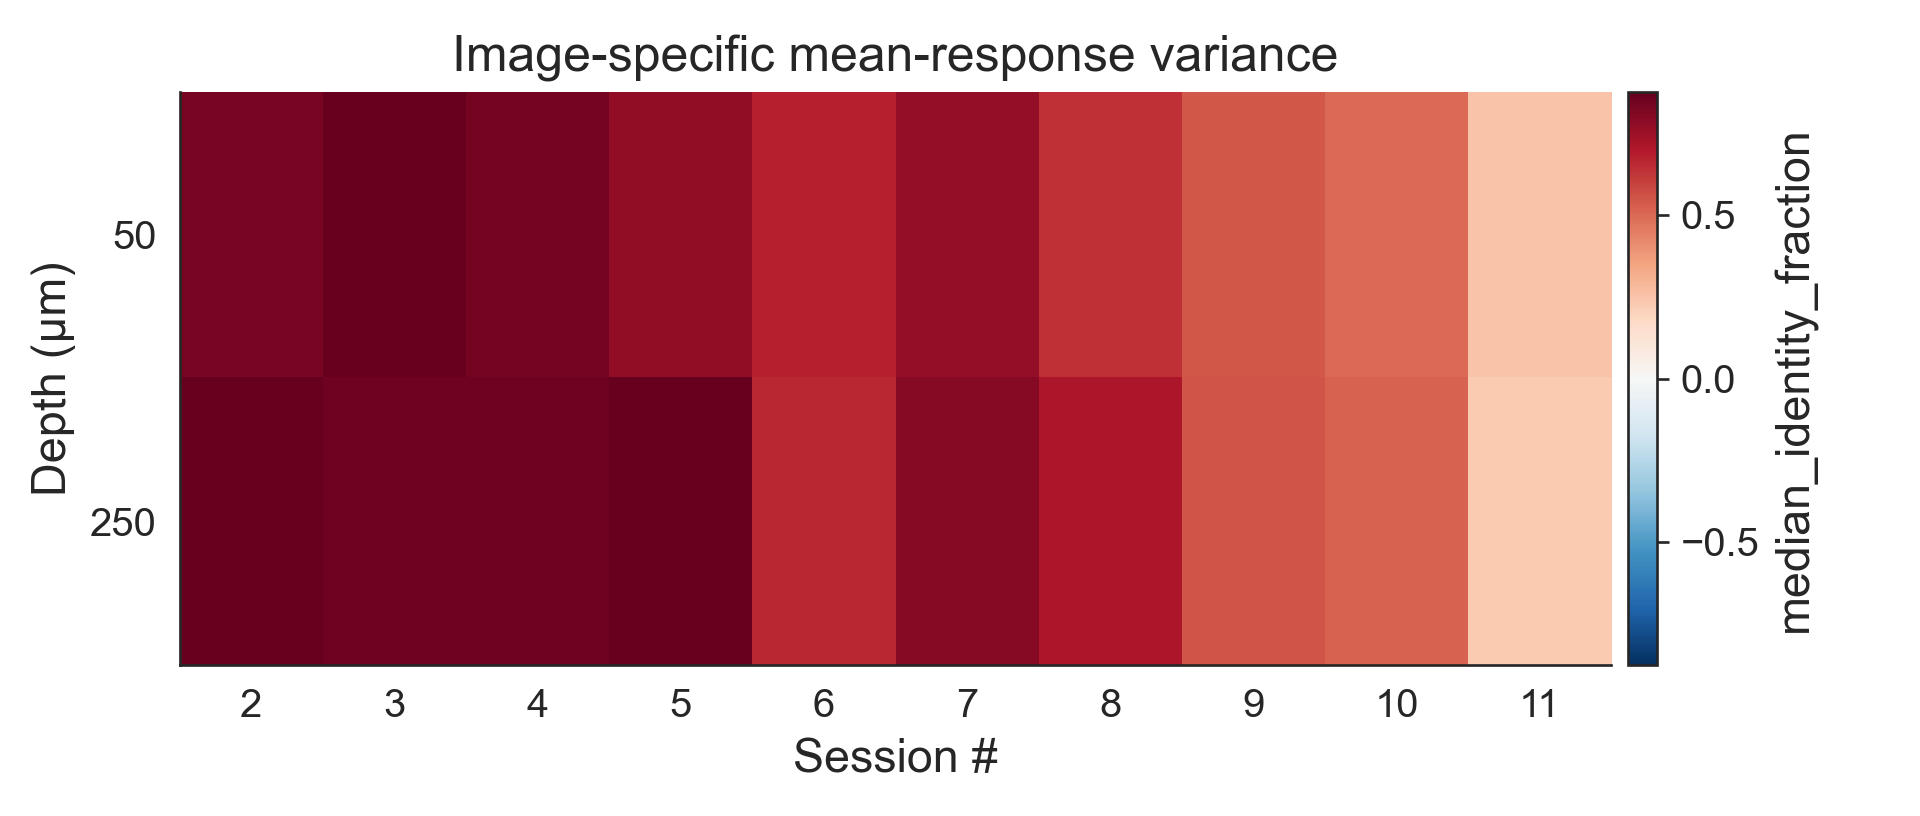

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_34996\1767640169.py:35: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8.0, 3.4))


<IPython.core.display.Javascript object>


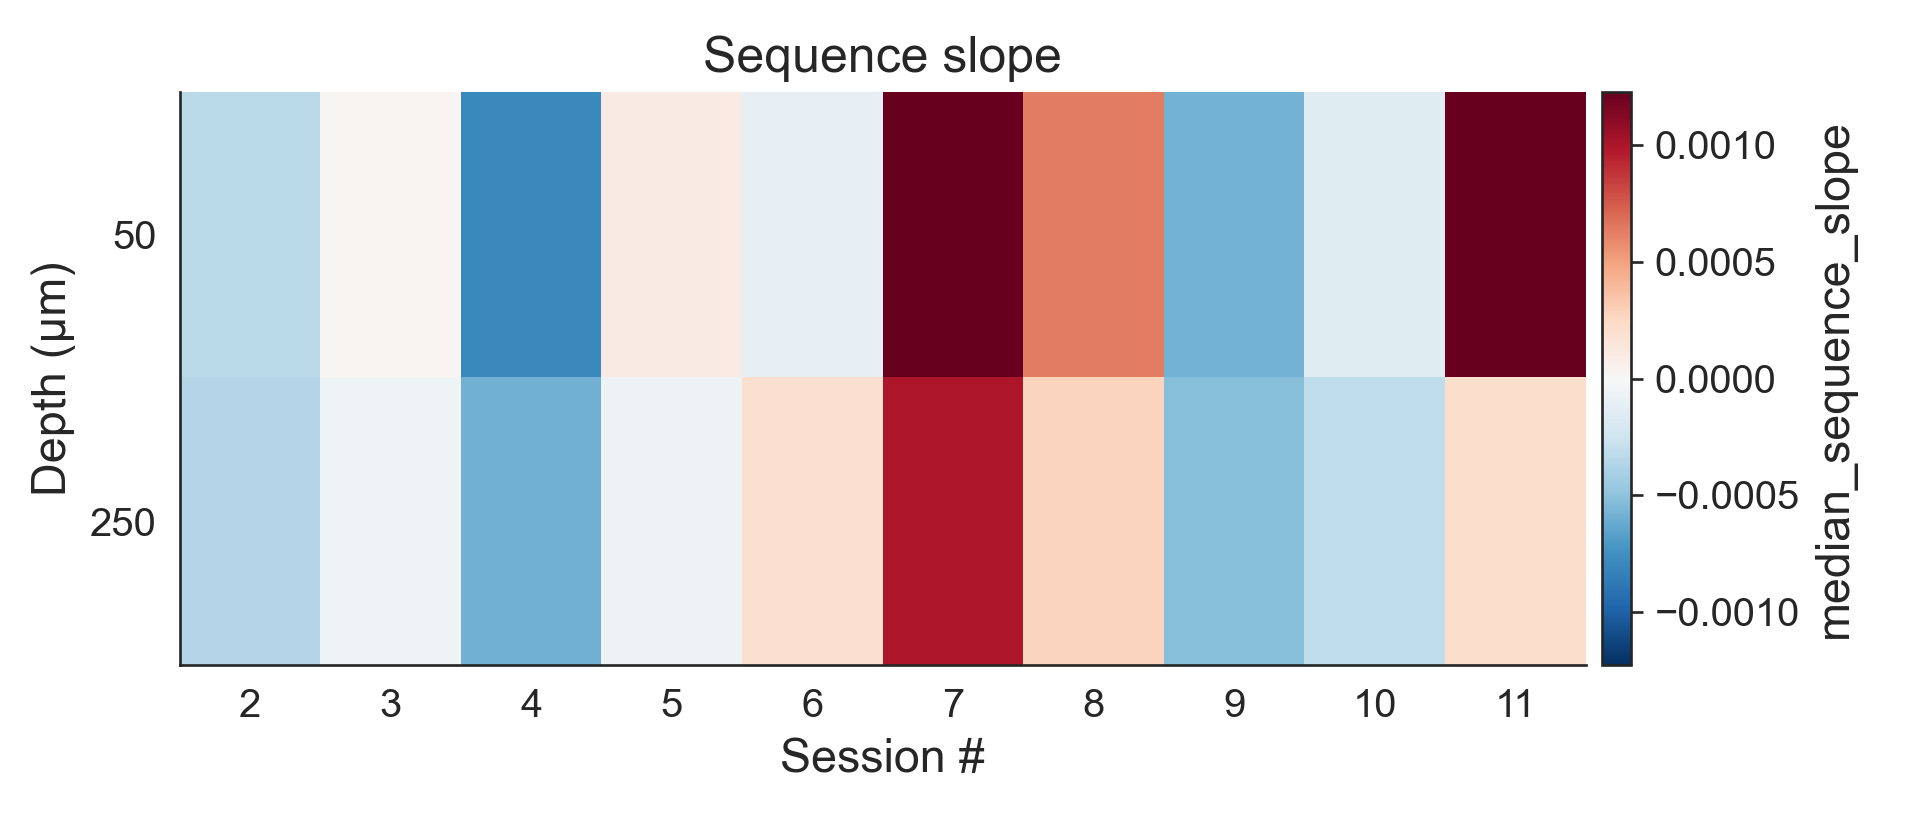

<IPython.core.display.Javascript object>


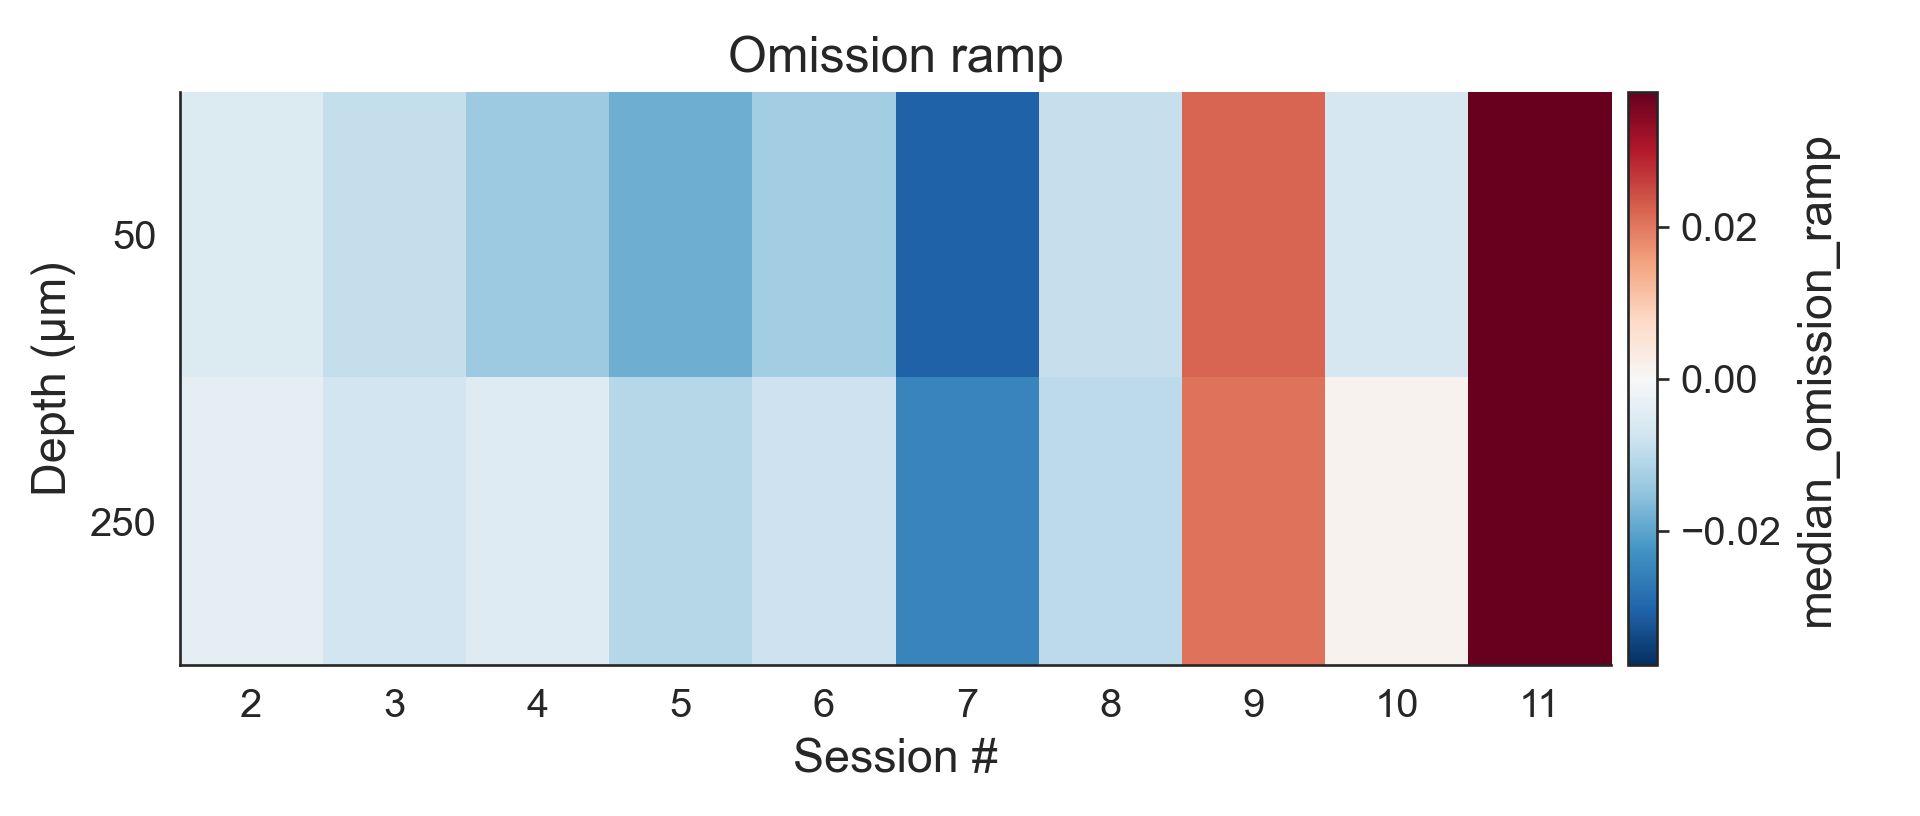

<IPython.core.display.Javascript object>


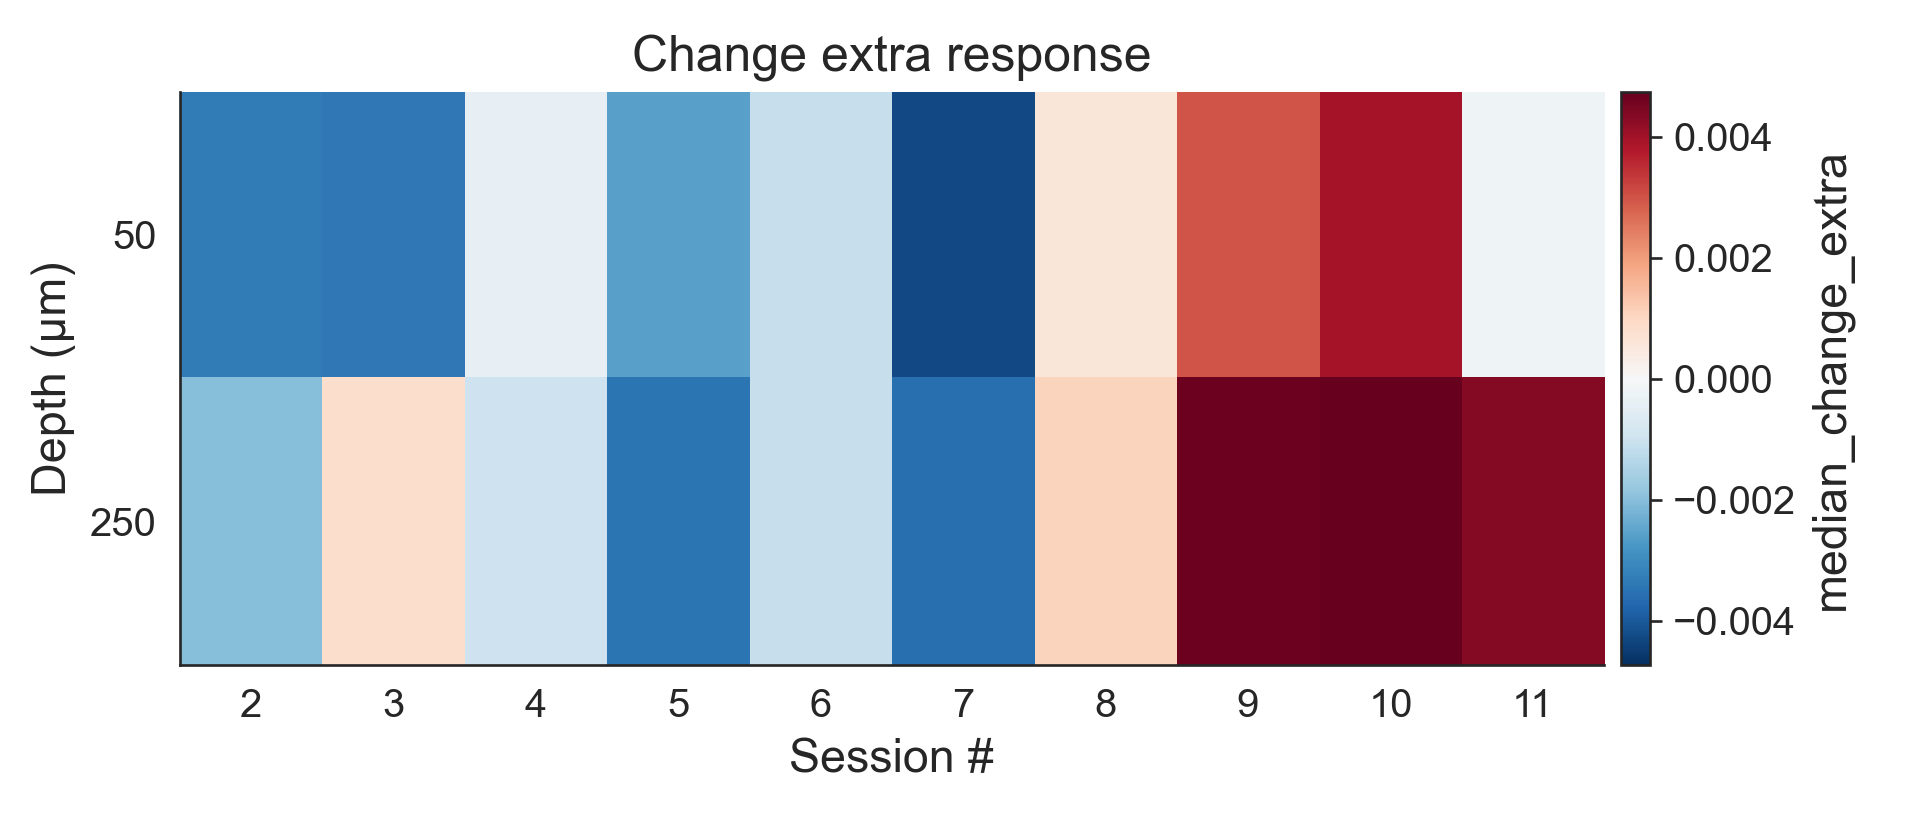

In [24]:

if len(roi_response_summary):
    dash = roi_response_summary.copy()
    if len(sequence_summary_df):
        dash = dash.merge(
            sequence_summary_df[["session_id", "dmd", "roi_idx", "median_sequence_slope", "median_adaptation_index", "sequence_class"]],
            on=["session_id", "dmd", "roi_idx"],
            how="left",
        )
    if len(event_response_df):
        omission = event_response_df.loc[event_response_df["event_type"].eq("omission"), ["session_id", "dmd", "roi_idx", "ramp_delta"]]
        change = event_response_df.loc[event_response_df["event_type"].eq("change"), ["session_id", "dmd", "roi_idx", "change_extra_delta"]]
        dash = dash.merge(omission, on=["session_id", "dmd", "roi_idx"], how="left")
        dash = dash.merge(change, on=["session_id", "dmd", "roi_idx"], how="left")

    # Aggregate to session x depth for heatmaps.
    agg = dash.groupby(["session_id", "session_number", "session_type", "depth_um"], dropna=False).agg(
        n_rois=("roi_id", "count"),
        frac_activated=("response_class", lambda x: np.mean(np.asarray(x) == "activated")),
        frac_suppressed=("response_class", lambda x: np.mean(np.asarray(x) == "suppressed")),
        median_identity_fraction=("identity_deviation_fraction", "median"),
        median_image_response=("preferred_abs_stim_delta", "median"),
        median_sequence_slope=("median_sequence_slope", "median"),
        median_omission_ramp=("ramp_delta", "median"),
        median_change_extra=("change_extra_delta", "median"),
    ).reset_index().sort_values(["session_number", "depth_um"])
    display(agg.head())

    for metric, title in [
        ("median_identity_fraction", "Image-specific mean-response variance"),
        ("median_sequence_slope", "Sequence slope"),
        ("median_omission_ramp", "Omission ramp"),
        ("median_change_extra", "Change extra response"),
    ]:
        pivot = agg.pivot_table(index="depth_um", columns="session_number", values=metric, aggfunc="median")
        fig, ax = plt.subplots(figsize=(8.0, 3.4))
        vmax = np.nanpercentile(np.abs(pivot.to_numpy(dtype=float)), 95) if np.isfinite(pivot.to_numpy(dtype=float)).any() else 1
        im = ax.imshow(pivot, aspect="auto", interpolation="nearest", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_yticks(np.arange(len(pivot.index)))
        ax.set_yticklabels([f"{d:g}" for d in pivot.index])
        ax.set_xticks(np.arange(len(pivot.columns)))
        ax.set_xticklabels([str(int(c)) if np.isfinite(c) else str(c) for c in pivot.columns], rotation=0)
        ax.set_xlabel("Session #")
        ax.set_ylabel("Depth (µm)")
        ax.set_title(title)
        cbar = fig.colorbar(im, ax=ax, pad=0.01)
        cbar.set_label(metric)
        clean_axes(ax)
        fig.tight_layout()
        maybe_savefig(fig, f"dashboard_heatmap_{metric}")

# Notes for next iterations

1. **Epoch/gap validation:** Run the H5 QC cell on sessions with multiple DI3 epochs. If `n_timebase_gaps_gt_5x_median` is nonzero and aligns to `imaging_epochs.csv`, gaps are represented in the full-session timebase. If multiple imaging epochs exist but no timebase gaps appear, the H5 is likely concatenated into acquisition time rather than behavior time and event alignment must use trial/epoch mapping explicitly.
2. **True FVE:** The mean NPZ supports image-mean variance metrics. Use the optional H5 single-trial cell for true trial-level image identity FVE.
3. **Running covariates:** Once the encoder speed is packaged per session using `8192` ticks/rev, add stationary/running stratified versions of the image, change, omission, and sequence metrics.
4. **Statistical unit:** For lab-meeting plots, show ROI-level points for discovery, but summarize inference at session/mouse level to avoid treating highly correlated dendrites as independent cells.
5. **Voltage-specific nuance:** Consider adding latency, derivative, and offset/rebound metrics after inspecting image PSTHs. These may be more informative than simple amplitude windows for ASAP7.